# 📘 Tutorial 4: Budget-Aware and Human-in-the-Loop BO Workflows

> This is the worked version of the notebook.
>
> All cells have been executed and include outputs, figures, and numerical results for reference.

In **Tutorial 3**, we extended Bayesian Optimisation from continuous and batched design spaces to a **mixed-variable, constrained experimental setting**, where raw BO proposals had to be interpreted through a full:

> **decode → repair → evaluate**

pipeline.

We saw that, even when the surrogate model and acquisition-based logic remain structurally familiar, the practical BO problem changes once the meaningful object of optimisation is no longer the raw latent point, but the **repaired feasible experiment**.

In particular, we saw that mixed-variable constrained BO requires us to think more carefully about:

- how to represent a design space that is not purely continuous,
- how to decode raw latent BO proposals into user-facing experimental settings,
- how to repair infeasible designs into runnable experiments,
- how to define a repaired objective over those feasible conditions,
- and how to distinguish between **latent-space novelty** and **repaired experimental novelty**.

That established mixed-variable constrained BO as a more realistic workflow for practical experimental optimisation.

In this tutorial, we take the next step:

> **what changes when BO is no longer judged only by the quality of the next experiment, but also by the cost of running it and the practical decision rules that shape whether it should be run at all?**

That is the focus of this notebook.

This is an important shift.

In the earlier tutorials, the main difficulty was still how to define and navigate the design space itself.
Even when the problem became higher-dimensional, batched, mixed-variable, or constrained, BO was still ultimately being asked to optimise **performance**.

That remains a useful baseline.

But in many realistic research settings, that is not the only thing that matters.

Instead, the next candidate may also need to be judged by:

- how expensive it is to run,
- whether the remaining budget can support it,
- whether a cheaper candidate could deliver similar value,
- and whether some form of human judgement would delay, discourage, or prioritise certain types of experiments.

Once that becomes true, the BO problem changes in a meaningful way.

A budget-aware and workflow-aware BO problem is not just:

- the same surrogate,
- plus the same acquisition function,
- plus a cost column added at the end.

It also introduces new practical questions:

- how to compare BO trajectories when experiments have unequal cost,
- how to decide whether a statistically attractive experiment is worth its price,
- how to evaluate performance by **BO iteration** versus **cumulative budget spent**,
- how to encode simple human-style preferences or veto rules,
- and how to compare workflows that differ not in the surrogate itself, but in **how they choose among feasible candidate experiments**.

So this tutorial is not mainly about introducing a completely different optimisation algorithm.

It is about learning how to adapt the BO workflow to a setting where **resource constraints and decision policy** are part of the optimisation problem itself.

To make this concrete, the notebook reuses the same synthetic **catalyst optimisation** problem from Tutorial 3, but now introduces:

- an explicit synthetic **cost model**,
- a **standard budget-limited BO** loop,
- a **budget-aware BO** loop that trades acquisition value against cost,
- and a **human-guided BO** loop that adds simple staged decision rules on top of the BO proposals.

That lets us study several core questions:

- how to attach a realistic notion of experimental cost to repaired designs,
- how to compare BO performance by **iteration** and by **cumulative cost**,
- how a budget-aware utility changes the kinds of experiments BO prefers,
- how many accepted evaluations different workflows can support under the same total budget,
- and how a simple human-in-the-loop policy can reshape the optimisation trajectory.

This is also where the notebook connects even more directly to real experimental optimisation.

In realistic research settings, the main challenge is often not just how to choose the next feasible experiment, but how to choose the next experiment that is:

- worth the cost,
- sensible at the current stage of the campaign,
- and compatible with the way real people actually make decisions under limited resources.

That is exactly the setting this tutorial is designed to approach.

---

**This tutorial is designed to shift perspective**
- from *“I can run BO in a mixed-variable, constrained experimental space”*
- to *“I can build and interpret BO when budget, cost, and human decision rules are part of the optimisation workflow itself.”*

---

**The emphasis is on developing intuition for**
- why cost-aware BO is not just ordinary BO with a stopping condition,
- why performance by **BO iteration** and by **cumulative cost** are not the same thing,
- how a budget-aware utility can lead BO to prefer cheaper but still valuable experiments,
- how workflow-level rules can reshape the search path without changing the surrogate model,
- and why human-in-the-loop BO can help or hurt depending on how the guidance policy is designed.

---

**Key ideas explored include**
- attaching a synthetic **experimental cost model** to repaired feasible designs,
- defining a **standard BO baseline under a fixed total budget**,
- constructing a **budget-aware BO loop** using an acquisition–cost utility,
- implementing a simple **human-guided BO workflow** with veto rules and soft preferences,
- comparing workflows by **best score over iteration** and **best score over cumulative cost**,
- analysing accepted candidate costs and evaluation counts,
- and interpreting veto behaviour as part of the optimisation story rather than as irrelevant bookkeeping.

---

This tutorial serves as the bridge from:

- **mixed-variable constrained BO** in Tutorial 3,
- to **budget-aware and human-shaped BO workflows** in more realistic experimental decision-making settings.

In other words:

- **Tutorial 3** showed how to build and interpret BO when the design space itself is mixed-variable, constrained, and experimentally structured,
- and **Tutorial 4** now asks what happens when candidate selection must also account for **cost, budget limits, and practical workflow judgement**.

---

**Recommended prerequisites**
- Completion of **Tutorials 1–3**
- Familiarity with Gaussian Process surrogates and acquisition functions in BoTorch
- Familiarity with the standard sequential BO loop
- Familiarity with mixed-variable BO, decoding, and repair
- Basic awareness that real experimental workflows are constrained not only by feasibility, but also by cost and practical decision-making

---

**Author**: Angze Li

**Last updated**: 2026-04-13

**Version**: v1.0

## 🔧 Setup

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.optim import optimize_acqf
from botorch.utils.sampling import draw_sobol_samples
from botorch.acquisition.analytic import LogExpectedImprovement

torch.set_default_dtype(torch.double)

def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=14)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")

This cell sets up the core optimisation problem for the notebook.

Importantly, this is **the same mixed-variable catalyst design space introduced in the previous notebook**.
So at the level of:

- the latent BO representation,
- the user-facing experimental variables,
- and the overall mixed-variable structure,

nothing fundamentally new is being introduced here.

That is deliberate.

The purpose of this tutorial is **not** to define a different optimisation problem.
Instead, it is to take the same mixed-variable catalyst setting from the last notebook and place it inside a new decision context:

> **what changes when BO must operate under an explicit experimental budget and more realistic workflow constraints?**

So this cell should be read as a continuation of the previous tutorial, not as a reset to a new problem.

---

### What stays the same as in the last notebook

The user-facing experimental design space remains:

- **temperature** in $[40,140]$
- **loading** in $[0.01, 0.20]$
- **reaction time** chosen from $\{10, 20, 30, 40, 50\}$
- **solvent** chosen from $\{\mathrm{A}, \mathrm{B}, \mathrm{C}\}$

So we are still working with a genuinely **mixed-variable** optimisation problem containing:

- continuous variables,
- a discrete variable,
- and a categorical variable.

This continuity is useful.

Because the design space is unchanged, any differences we observe later in the notebook can be interpreted as coming mainly from the **budget-aware and human-guided workflow logic**, rather than from a completely new objective or search space.

---

### The latent BO representation

As in the previous notebook, BO is not run directly on the user-facing catalyst variables.

Instead, the optimiser works in a **4-dimensional latent unit box**:

$$
[0,1]^4
$$

with coordinates corresponding to:

- `temp_raw`
- `loading_raw`
- `time_raw`
- `solvent_raw`

This is why the code defines:

```python
latent_dim = 4
latent_bounds = torch.tensor(
    [[0.0] * latent_dim, [1.0] * latent_dim],
    dtype=torch.double,
)
```

So again, the BO machinery will operate in a continuous latent space, and later cells will decode and repair those raw proposals into actual experimental conditions.

That is exactly the same modelling strategy used in the previous tutorial.

---

### Why the seed is set again

The notebook begins with:

```python
seed = 6
torch.manual_seed(seed)
```

This is simply to keep the notebook reproducible.

Because later parts of the workflow involve:

- Sobol initial designs,
- candidate pools,
- and stochastic proposal construction,

fixing the seed makes it easier to compare runs consistently.

So this is not a new modelling ingredient.
It is just part of making the tutorial stable and readable.

---

### What is new in this notebook

The genuinely new quantity introduced in this cell is:

```python
budget_total = 60.0
```

This is the key new ingredient of the tutorial.

In the previous notebook, BO was mainly concerned with:

- handling mixed variables,
- repairing infeasible designs,
- and reasoning in terms of repaired experimental novelty.

Here, the focus shifts to a different practical question:

> **how should BO behave when the total experimental budget is limited?**

That means this notebook is not only about finding good designs, but also about deciding:

- which experiments are worth spending budget on,
- whether expensive high-performing conditions should be pursued immediately,
- whether cheaper alternatives can deliver similar value,
- and how human preferences or workflow rules might reshape those decisions.

So the design space is reused, but the **decision environment** is different.

---

### The role of `n_init = 8`

The line

```python
n_init = 8
```

sets the size of the initial dataset.

As in the previous notebook, this initial design serves as the starting point from which BO begins updating its surrogate and making sequential decisions.

Conceptually, this notebook treats the initial dataset as **already available prior data**, while the later budget will apply to **new BO-guided decisions**.

That interpretation is important, because otherwise the entire budget could be consumed too early by the initial dataset itself.

So `n_init` here defines the starting information available to BO before the workflow-level policies begin to matter.

---

### Why the variable-name lists are retained

The lists

```python
latent_variable_names = ["temp_raw", "loading_raw", "time_raw", "solvent_raw"]
experimental_variable_names = ["temperature", "loading", "time", "solvent"]
```

are the same style as before and are kept mainly for clarity and readability.

They help maintain the distinction between:

- the **latent raw proposal space**, where BO operates numerically,
- and the **experimental design space**, where the actual repaired catalyst conditions live.

That distinction remains central in this notebook as well.

---

### What the printed output confirms

The printed output simply acts as a quick sanity check that the reused mixed-variable problem has been loaded correctly:

- latent dimension = 4
- initial design size = 8
- total budget = 60.0
- latent bounds shape = `(2, 4)`
- experimental variables are correctly named

So this output is not analytically deep, but it confirms that the notebook is beginning from the intended shared problem setup.

---

### Key takeaway

This cell re-establishes **the same mixed-variable catalyst optimisation problem as in the previous notebook**, including the same latent-space BO representation and the same four user-facing experimental variables.

The important new addition is the introduction of a **total experimental budget**, which shifts the focus from merely finding good feasible designs to deciding **how BO should spend limited experimental resources**.

So the problem itself stays the same, but the workflow question becomes more realistic.

In [2]:
seed = 6
torch.manual_seed(seed)

# User-facing experimental design space
TEMP_MIN, TEMP_MAX = 40.0, 140.0
LOAD_MIN, LOAD_MAX = 0.01, 0.20
TIME_LEVELS = np.array([10, 20, 30, 40, 50], dtype=float)
SOLVENTS = ["A", "B", "C"]

latent_dim = 4
latent_bounds = torch.tensor(
    [[0.0] * latent_dim, [1.0] * latent_dim],
    dtype=torch.double,
)

n_init = 8
budget_total = 60.0

latent_variable_names = ["temp_raw", "loading_raw", "time_raw", "solvent_raw"]
experimental_variable_names = ["temperature", "loading", "time", "solvent"]

print("Latent dimension:", latent_dim)
print("Initial design size:", n_init)
print("Total budget:", budget_total)
print("Latent bounds shape:", tuple(latent_bounds.shape))
print("Experimental variables:", experimental_variable_names)

Latent dimension: 4
Initial design size: 8
Total budget: 60.0
Latent bounds shape: (2, 4)
Experimental variables: ['temperature', 'loading', 'time', 'solvent']


## 2. Reusing the decode–repair–evaluate pipeline from the previous notebook

This cell reintroduces the core modelling machinery from the last notebook.

Importantly, this is **the same decode–repair–evaluate pipeline used in Tutorial 3**.
So at the level of:

- decoding latent BO proposals into experimental variables,
- repairing infeasible decoded designs into feasible catalyst settings,
- defining the repaired synthetic catalyst score,
- and converting batches into readable dataframes,

nothing fundamentally new is being introduced here.

That continuity is deliberate.

The goal of this tutorial is **not** to redesign the underlying mixed-variable constrained optimisation problem from scratch.
Instead, it is to place the same problem inside a new workflow setting where:

- evaluation cost matters,
- the total budget is limited,
- and different BO decision policies can be compared.

So this cell serves mainly to make the notebook self-contained while keeping the problem definition consistent with the previous tutorial.

---

### What this cell contains

As in the last notebook, the code is organised into four main parts:

#### 1. Decoding
The `decode_*` functions map raw latent coordinates in $[0,1]^4$ into user-facing experimental variables:

- temperature,
- loading,
- reaction time,
- and solvent.

This is the same latent-to-experimental translation step as before.

#### 2. Repair
The `repair_single_design(...)` function enforces the same solvent-dependent feasibility rules introduced in Tutorial 3.

So decoded designs are again mapped into valid catalyst settings through:

- solvent-specific temperature windows,
- solvent-specific loading windows,
- solvent-specific allowed time levels,
- and the high-temperature compatibility rule forcing solvent C.

#### 3. Repaired objective
The `SOLVENT_PARAMS`, `evaluate_repaired_design(...)`, and `objective_mixed_raw(...)` definitions are also the same as before.

So the objective being optimised is still the same repaired synthetic catalyst score used in the previous notebook.

This is important because it means that any behavioural differences we observe later are mainly due to the **budget-aware and human-guided workflow logic**, not because the underlying catalyst problem itself has changed.

#### 4. Dataframe helper
The `batch_to_dataframe(...)` helper is again included so that raw latent candidates, decoded designs, repaired designs, scores, and costs can be viewed in a readable tabular form.

This is just as useful here as it was in the previous notebook.

---

### Why this is being reused

Reusing exactly the same pipeline is valuable because it keeps the comparison clean.

If both the design space and the repaired objective changed at the same time as the workflow logic, it would be much harder to interpret the results.

By keeping the same mixed-variable constrained catalyst problem from Tutorial 3, this notebook can focus on a new question:

> **How should BO behave when experimental decisions are no longer judged only by score, but also by budget and workflow constraints?**

So this cell is best understood as the **shared problem-definition layer** carried forward from the previous tutorial.

---

### Key takeaway

This cell simply reinstates the **same decode–repair–evaluate framework from the last notebook**.

The catalyst problem, the repair rules, and the repaired synthetic objective are unchanged.

That is intentional, because it allows this tutorial to focus on what is new:

- cost-aware decision-making,
- budget-limited optimisation,
- and human-guided BO workflow design.

In [3]:
def decode_temperature(raw_t):
    raw_t = float(np.clip(raw_t, 0.0, 1.0))
    continuous_temperature = TEMP_MIN + raw_t * (TEMP_MAX - TEMP_MIN)
    snapped_temperature = 5.0 * round(continuous_temperature / 5.0)
    snapped_temperature = float(np.clip(snapped_temperature, TEMP_MIN, TEMP_MAX))
    return snapped_temperature

def decode_loading(raw_l):
    raw_l = float(np.clip(raw_l, 0.0, 1.0))
    continuous_loading = LOAD_MIN + raw_l * (LOAD_MAX - LOAD_MIN)
    snapped_loading = 0.01 * round(continuous_loading / 0.01)
    snapped_loading = float(np.clip(snapped_loading, LOAD_MIN, LOAD_MAX))
    return snapped_loading

def decode_time(raw_time):
    raw_time = float(np.clip(raw_time, 0.0, 1.0))
    continuous_time = TIME_LEVELS[0] + raw_time * (TIME_LEVELS[-1] - TIME_LEVELS[0])
    idx = int(np.argmin(np.abs(TIME_LEVELS - continuous_time)))
    return int(TIME_LEVELS[idx])

def decode_solvent(raw_solvent):
    raw_solvent = float(np.clip(raw_solvent, 0.0, 1.0))
    if raw_solvent < 1.0 / 3.0:
        return "A"
    if raw_solvent < 2.0 / 3.0:
        return "B"
    return "C"

def decode_single_design(x_raw):
    x = x_raw.detach().cpu().numpy().reshape(-1)
    return {
        "temperature": decode_temperature(x[0]),
        "loading": decode_loading(x[1]),
        "time": decode_time(x[2]),
        "solvent": decode_solvent(x[3]),
    }

def decode_batch(X_raw):
    return [decode_single_design(x_raw) for x_raw in X_raw]

def nearest_allowed_time(time_value, allowed_times):
    allowed_times = np.array(sorted(allowed_times), dtype=int)
    idx = int(np.argmin(np.abs(allowed_times - int(time_value))))
    return int(allowed_times[idx])

def repair_single_design(decoded_design):
    repaired = dict(decoded_design)
    repair_flags = []

    # Cross-variable rule: temperatures above 110 C are only compatible with solvent C.
    if repaired["temperature"] > 110.0 and repaired["solvent"] != "C":
        repaired["solvent"] = "C"
        repair_flags.append("high_temp_requires_C")

    if repaired["solvent"] == "A":
        if repaired["temperature"] < 65.0:
            repaired["temperature"] = 65.0
            repair_flags.append("A_temp_floor")
        if repaired["temperature"] > 85.0:
            repaired["temperature"] = 85.0
            repair_flags.append("A_temp_cap")
        if repaired["loading"] > 0.12:
            repaired["loading"] = 0.12
            repair_flags.append("A_loading_cap")

        repaired_time = nearest_allowed_time(repaired["time"], [10, 20])
        if repaired_time != repaired["time"]:
            repaired["time"] = repaired_time
            repair_flags.append("A_time_window")

    elif repaired["solvent"] == "B":
        if repaired["temperature"] < 88.0:
            repaired["temperature"] = 88.0
            repair_flags.append("B_temp_floor")
        if repaired["temperature"] > 108.0:
            repaired["temperature"] = 108.0
            repair_flags.append("B_temp_cap")
        if repaired["loading"] > 0.13:
            repaired["loading"] = 0.13
            repair_flags.append("B_loading_cap")
        if repaired["loading"] < 0.08:
            repaired["loading"] = 0.08
            repair_flags.append("B_loading_floor")

        repaired_time = nearest_allowed_time(repaired["time"], [20, 30])
        if repaired_time != repaired["time"]:
            repaired["time"] = repaired_time
            repair_flags.append("B_time_window")

    elif repaired["solvent"] == "C":
        if repaired["temperature"] < 118.0:
            repaired["temperature"] = 118.0
            repair_flags.append("C_temp_floor")
        if repaired["temperature"] > 132.0:
            repaired["temperature"] = 132.0
            repair_flags.append("C_temp_cap")
        if repaired["loading"] < 0.06:
            repaired["loading"] = 0.06
            repair_flags.append("C_loading_floor")
        if repaired["loading"] > 0.10:
            repaired["loading"] = 0.10
            repair_flags.append("C_loading_cap")

        repaired_time = nearest_allowed_time(repaired["time"], [40, 50])
        if repaired_time != repaired["time"]:
            repaired["time"] = repaired_time
            repair_flags.append("C_time_window")

    repaired["was_repaired"] = len(repair_flags) > 0
    repaired["repair_flags"] = repair_flags
    repaired["repair_count"] = len(repair_flags)
    return repaired

def repair_batch(decoded_batch):
    return [repair_single_design(d) for d in decoded_batch]

def repaired_design_key(repaired_design):
    return (
        int(round(float(repaired_design["temperature"]))),
        round(float(repaired_design["loading"]), 2),
        int(repaired_design["time"]),
        repaired_design["solvent"],
    )

SOLVENT_PARAMS = {
    "A": {
        "base": 40.0,
        "amp": 22.0,
        "T_opt": 75.0,
        "L_opt": 0.09,
        "sigma_T": 5.0,
        "sigma_L": 0.010,
        "time_opt": 20,
        "time_penalty": 0.16,
        "bonus": 0.0,
    },
    "B": {
        "base": 42.0,
        "amp": 28.0,
        "T_opt": 98.0,
        "L_opt": 0.12,
        "sigma_T": 5.5,
        "sigma_L": 0.010,
        "time_opt": 30,
        "time_penalty": 0.15,
        "bonus": 0.5,
    },
    "C": {
        "base": 46.0,
        "amp": 38.0,
        "T_opt": 125.0,
        "L_opt": 0.08,
        "sigma_T": 4.5,
        "sigma_L": 0.008,
        "time_opt": 40,
        "time_penalty": 0.14,
        "bonus": 2.5,
    },
}

def evaluate_repaired_design(repaired_design):
    p = SOLVENT_PARAMS[repaired_design["solvent"]]
    T = float(repaired_design["temperature"])
    L = float(repaired_design["loading"])
    t = int(repaired_design["time"])
    solvent = repaired_design["solvent"]

    continuous_peak = p["amp"] * np.exp(
        -0.5 * ((T - p["T_opt"]) / p["sigma_T"]) ** 2
        -0.5 * ((L - p["L_opt"]) / p["sigma_L"]) ** 2
    )

    time_term = -p["time_penalty"] * (t - p["time_opt"]) ** 2
    interaction_term = 0.8 * np.sin(T / 9.0) * np.cos(35.0 * L)

    edge_penalty = 0.0
    if solvent == "A" and T == 85.0:
        edge_penalty -= 4.0
    if solvent == "B" and (T == 88.0 or T == 108.0 or L == 0.13):
        edge_penalty -= 2.5
    if solvent == "C" and (T == 118.0 or T == 132.0 or L == 0.06 or L == 0.10):
        edge_penalty -= 1.2

    ridge_term = {
        "A": -0.020 * (T - 72.0) * (L - 0.09) * 100.0,
        "B": 0.015 * (T - 96.0) * (L - 0.11) * 100.0,
        "C": 0.025 * (T - 122.0) * (0.09 - L) * 100.0,
    }[solvent]

    score = p["base"] + p["bonus"] + continuous_peak + time_term + interaction_term + ridge_term + edge_penalty
    return float(score)

def objective_mixed_raw(X_raw):
    if X_raw.ndim == 1:
        X_raw = X_raw.unsqueeze(0)

    scores = []
    for x_raw in X_raw:
        decoded = decode_single_design(x_raw)
        repaired = repair_single_design(decoded)
        scores.append(evaluate_repaired_design(repaired))

    return torch.tensor(scores, dtype=torch.double).unsqueeze(-1)

def batch_to_dataframe(X_raw, Y=None, costs=None):
    if X_raw.ndim == 1:
        X_raw = X_raw.unsqueeze(0)

    rows = []
    Y_vals = None if Y is None else Y.detach().cpu().view(-1).tolist()
    cost_vals = None if costs is None else list(costs)

    for i, x_raw in enumerate(X_raw):
        x_np = x_raw.detach().cpu().numpy().reshape(-1)
        decoded = decode_single_design(x_raw)
        repaired = repair_single_design(decoded)

        row = {
            "temp_raw": float(x_np[0]),
            "loading_raw": float(x_np[1]),
            "time_raw": float(x_np[2]),
            "solvent_raw": float(x_np[3]),
            "decoded_temperature": decoded["temperature"],
            "decoded_loading": decoded["loading"],
            "decoded_time": decoded["time"],
            "decoded_solvent": decoded["solvent"],
            "repaired_temperature": repaired["temperature"],
            "repaired_loading": repaired["loading"],
            "repaired_time": repaired["time"],
            "repaired_solvent": repaired["solvent"],
            "was_repaired": repaired["was_repaired"],
            "repair_count": repaired["repair_count"],
            "repair_flags": ", ".join(repaired["repair_flags"]) if repaired["repair_flags"] else "None",
        }

        if Y_vals is not None:
            row["score"] = Y_vals[i]
        if cost_vals is not None:
            row["cost"] = cost_vals[i]

        rows.append(row)

    return pd.DataFrame(rows)

## 3. Adding a synthetic evaluation cost model

This cell introduces the new ingredient that distinguishes this notebook from the previous one: a **cost model** for running experiments.

Up to this point, the mixed-variable catalyst problem has been exactly the same as in the last notebook.
We still have:

- the same latent BO representation,
- the same decode step,
- the same repair logic,
- and the same repaired synthetic catalyst score.

What changes here is that experiments are no longer treated as if they all cost the same.

Instead, each repaired feasible design is now assigned an explicit **evaluation cost**.

That is the core idea of the tutorial.

---

### Why a cost model is needed

In realistic optimisation settings, not all experiments are equally easy or equally cheap to run.

For example, an experiment may cost more because it involves:

- a more expensive solvent,
- a longer reaction time,
- a higher temperature regime,
- or a more demanding operating condition.

So if the goal of this tutorial is to make BO more workflow-aware, then it is no longer enough to ask only:

> **Which candidate has the best expected score?**

We also need to ask:

> **Which candidate is worth running given its experimental cost?**

That is why this notebook introduces a cost function in addition to the repaired objective.

---

### What this cost model does

The function `evaluate_cost(repaired_design)` assigns a synthetic experimental cost to each repaired catalyst design.

The cost depends on:

- **solvent**
- **reaction time**
- **temperature**
- and, in one case, **loading**

The structure is intentionally simple:

- solvent A is cheapest
- solvent B is more expensive
- solvent C is much more expensive
- longer reaction times cost more
- high-temperature conditions cost more
- very high loading can add a further cost penalty

So this makes some regions of the repaired design space much more expensive than others.

That is exactly the behaviour needed for a budget-aware tutorial.

---

### Why the cost depends on the repaired design

As with the score, the cost is evaluated on the **repaired experimental design**, not on the raw latent point.

That is important.

A raw latent proposal is not itself a real experiment.
The real experiment is the repaired feasible catalyst condition that would actually be run.

So the cost model follows the same logic as the objective:

> **latent proposal → decode → repair → cost**

This keeps the workflow internally consistent.

---

### What `evaluate_cost_raw(...)` does

The helper function `evaluate_cost_raw(X_raw)` simply applies the same logic to a batch of raw latent candidates:

1. decode each raw point,
2. repair it into a feasible design,
3. compute its experimental cost.

This is useful because later parts of the notebook work with batches of latent points rather than single examples.

So this helper plays the same role for cost that `objective_mixed_raw(...)` plays for score.

---

### Why these costs should be interpreted carefully

It is important to state explicitly that these costs are **synthetic**.

They are designed to make the workflow more realistic, but they are still **made-up data**.

So although the cost structure is inspired by plausible experimental reasoning — for example, expensive solvents, long reactions, and hot conditions often being more costly — the numerical values here are **not calibrated to a real laboratory system**.

That means they should be treated with care.

The purpose of the cost model is **not** to claim that these are the true costs of catalyst optimisation experiments.
Its purpose is to create a controlled toy setting in which we can study:

- unequal evaluation cost,
- limited total budget,
- and how BO behaviour changes when cost matters.

So this section is trying to be more practical than the previous notebook, but it is still a **synthetic tutorial model**, not a real costing framework.

---

### Why this is still useful

Even though the numbers are artificial, this cost model is still very useful.

It lets the notebook ask realistic workflow questions such as:

- should BO spend budget immediately on the most expensive high-performing region?
- can a cheaper candidate provide nearly the same benefit?
- how should we compare optimisation strategies when score and cost both matter?

Those are real questions, even if the exact cost values here are illustrative rather than experimental.

So the cost model should be understood as a **practical teaching device**:
simple enough to be transparent, but structured enough to make budget-aware BO behaviour meaningful.

---

### Key takeaway

This cell adds a synthetic **experimental cost model** on top of the same repaired catalyst optimisation problem used in the previous notebook.

The cost depends on repaired solvent, time, temperature, and in one case loading, so different feasible experiments are no longer treated as equally cheap.

This is what makes it possible to study **budget-aware BO workflows** in the rest of the notebook.

At the same time, these costs are still **made-up tutorial data**, so while they are intended to feel practically motivated, they should be interpreted with care rather than as real laboratory cost estimates.

In [4]:
def evaluate_cost(repaired_design):
    solvent = repaired_design["solvent"]
    T = float(repaired_design["temperature"])
    t = int(repaired_design["time"])
    L = float(repaired_design["loading"])

    # Stronger cost asymmetry so budget really matters.
    solvent_cost = {"A": 1.0, "B": 2.8, "C": 8.0}[solvent]
    time_cost = {10: 0.0, 20: 0.6, 30: 1.4, 40: 2.8, 50: 3.8}[t]
    high_temp_cost = 3.5 if T >= 120.0 else (1.5 if T >= 100.0 else 0.0)
    loading_cost = 0.8 if L >= 0.12 else 0.0

    return float(solvent_cost + time_cost + high_temp_cost + loading_cost)


def evaluate_cost_raw(X_raw):
    if X_raw.ndim == 1:
        X_raw = X_raw.unsqueeze(0)

    costs = []
    for x_raw in X_raw:
        decoded = decode_single_design(x_raw)
        repaired = repair_single_design(decoded)
        costs.append(evaluate_cost(repaired))

    return costs

## 4. Generating and inspecting the initial dataset

With the mixed-variable catalyst problem and the synthetic cost model now defined, we can generate the initial dataset that all later BO workflows will start from.

As in the previous tutorials, this initial dataset is produced using a **Sobol design** in the latent BO space.
So the first step is still familiar:

- draw an initial set of latent points,
- evaluate them through the full pipeline,
- and inspect what those points correspond to in the repaired experimental design space.

What makes this notebook different is that the initial dataset is now inspected not only in terms of **score**, but also in terms of **cost**.

That is important, because later workflow comparisons will depend on both.

---

### What the code does

The first line resets the random seed:

```python
torch.manual_seed(seed)
```

This keeps the Sobol initial design reproducible.

The next line draws `n_init` Sobol points in the latent unit box:

```python
train_X_init = draw_sobol_samples(bounds=latent_bounds, n=1, q=n_init).squeeze(0)
```

So `train_X_init` contains the raw latent initial design.

The line

```python
train_Y_init = objective_mixed_raw(train_X_init)
```

evaluates each latent point through the full **decode → repair → score** pipeline, giving the repaired catalyst score for each point.

Then:

```python
train_costs_init = evaluate_cost_raw(train_X_init)
```

computes the synthetic cost of each repaired experimental design corresponding to those same latent points.

So at this point, the notebook has an initial dataset with two associated quantities for every candidate:

- a repaired **score**
- and a repaired **cost**

---

### Why this initial dataset matters

This dataset plays the same role as in the previous notebook: it is the information BO begins with before any sequential decision-making takes place.

Conceptually, the tutorial treats this initial set as **already available prior data**.

That means the later BO workflow will start from these observations, but the budget-aware policies introduced afterward are meant to govern the **new BO-guided decisions**, not the already existing initial dataset.

This is why the initial total cost is printed for inspection, but the later BO loops are still allowed to begin with a fresh running budget.

---

### What the dataframe is showing

The line

```python
initial_df = batch_to_dataframe(train_X_init, train_Y_init, train_costs_init)
```

converts the initial dataset into a readable table.

This makes it possible to inspect, for each initial latent point:

- the raw latent coordinates,
- the decoded experimental variables,
- the repaired feasible design,
- the repaired score,
- and the repaired cost.

This is especially useful in a mixed-variable constrained setting, because the raw latent points themselves are not directly meaningful experiments.
The dataframe makes it much easier to see what BO is actually starting from.

---

### Why the initial repaired solvent counts are useful

The final lines print the counts of repaired solvents in the initial dataset:

```python
print(initial_df["repaired_solvent"].value_counts())
```

This gives a quick view of how the initial design is distributed across the three repaired solvent regimes.

That is useful because the catalyst problem is structured quite differently depending on solvent:

- solvent A corresponds to one feasible subregion,
- solvent B to another,
- solvent C to another.

So these counts tell us whether the initial design already covers a reasonably diverse set of repaired experimental regimes.

This matters because a BO workflow that starts with observations from all three solvent families may behave differently from one that begins with a much narrower initial repaired set.

---

### How to interpret the printed total initial cost

The line

```python
print("Initial total cost if all are run:", float(np.sum(train_costs_init)))
```

should be interpreted carefully.

This is **not** the same as saying that the BO workflow has already spent that much of its active optimisation budget.

Instead, it is simply reporting the total synthetic cost of the already-available initial dataset.

So this number is useful as a reference point for understanding the scale of the cost model, but it is not the running cost used inside the later BO loops.

---

### Key takeaway

This cell generates the initial Sobol design in latent space and evaluates it through both:

- the repaired synthetic catalyst **score**
- and the repaired synthetic **cost**

So the initial dataset is now characterised not only by performance, but also by experimental expense.

That makes it the natural starting point for the budget-aware and human-guided BO workflows that follow.

In [5]:
torch.manual_seed(seed)

train_X_init = draw_sobol_samples(bounds=latent_bounds, n=1, q=n_init).squeeze(0)
train_Y_init = objective_mixed_raw(train_X_init)
train_costs_init = evaluate_cost_raw(train_X_init)

print("Initial latent design shape:", tuple(train_X_init.shape))
print("Initial score shape:", tuple(train_Y_init.shape))
print("Initial best observed score:", float(torch.max(train_Y_init)))
print("Initial total cost if all are run:", float(np.sum(train_costs_init)))

initial_df = batch_to_dataframe(train_X_init, train_Y_init, train_costs_init)
display(initial_df)

print("Initial repaired solvent counts:")
print(initial_df["repaired_solvent"].value_counts())

Initial latent design shape: (8, 4)
Initial score shape: (8, 1)
Initial best observed score: 47.509718073109276
Initial total cost if all are run: 51.8


,temp_raw,loading_raw,time_raw,solvent_raw,decoded_temperature,decoded_loading,decoded_time,decoded_solvent,repaired_temperature,repaired_loading,repaired_time,repaired_solvent,was_repaired,repair_count,repair_flags,score,cost
0,0.689666,0.278232,0.771052,0.673455,110.0,0.06,40,C,118.0,0.06,40,C,True,1,C_temp_floor,47.288645,12.3
1,0.759167,0.043482,0.933570,0.078998,115.0,0.02,50,A,118.0,0.06,50,C,True,3,"high_temp_requires_C, C_temp_floor, C_loading_...",33.288645,13.3
2,0.014981,0.440072,0.119953,0.486687,40.0,0.09,10,B,88.0,0.09,20,B,True,2,"B_temp_floor, B_time_window",25.576127,3.4
3,0.166035,0.462993,0.466580,0.169596,55.0,0.10,30,A,65.0,0.10,20,A,True,2,"A_temp_floor, A_time_window",41.341301,1.6
4,0.558122,0.611953,0.267596,0.911915,95.0,0.13,20,C,118.0,0.10,40,C,True,3,"C_temp_floor, C_loading_cap, C_time_window",47.509718,12.3
5,0.681695,0.724740,0.331416,0.648392,110.0,0.15,20,B,108.0,0.13,20,B,True,2,"B_temp_cap, B_loading_cap",28.681537,5.7
6,0.574852,0.160141,0.167172,0.085792,95.0,0.04,20,A,85.0,0.04,20,A,True,1,A_temp_cap,37.297337,1.6
7,0.028768,0.234328,0.718455,0.096851,45.0,0.05,40,A,65.0,0.05,20,A,True,2,"A_temp_floor, A_time_window",39.325925,1.6


Initial repaired solvent counts:
repaired_solvent
C    3
A    3
B    2
Name: count, dtype: int64


## 5. Defining the standard BO loop under a fixed total budget

This cell defines the first workflow-specific BO loop of the notebook: a **standard sequential BO loop with a budget constraint**.

Conceptually, this is **the same standard BO loop we have used before**.

It still follows the familiar pattern:

1. start from an initial dataset,
2. fit a Gaussian Process surrogate,
3. build an acquisition function,
4. optimise the acquisition function to select the next candidate,
5. evaluate the objective there,
6. update the dataset,
7. and repeat.

So the BO mechanics themselves are unchanged.

The important new addition is simply that the loop now keeps track of **experimental cost**, and stops once the next candidate would cause the total budget to be exceeded.

So this function should be understood as:

> **standard sequential BO, with the extra practical constraint of a fixed total budget**

---

### What stays the same as before

As in earlier tutorials, the loop:

- fits a `SingleTaskGP` surrogate at each step,
- normalises the inputs,
- standardises the outputs,
- uses `LogExpectedImprovement` as the acquisition function,
- and proposes one new point at a time by optimising that acquisition function.

So if we ignore the cost bookkeeping, this is exactly the same standard BO workflow already used in the earlier notebooks.

That is important because it gives us a clean baseline.

Any differences we see later when comparing against budget-aware BO or human-guided BO will not be due to a different surrogate model or a different acquisition function.
They will come from the **decision policy added on top of the same standard BO machinery**.

---

### What is new here

The genuinely new element is the running cost variable:

```python
cumulative_cost = 0.0
```

and the budget check:

```python
if cumulative_cost + candidate_cost > budget_total:
    break
```

This means that standard BO is still trying to choose the candidate with the best acquisition value, exactly as before, but now it is no longer allowed to continue indefinitely.

Instead, it must stop once the next proposed experiment would exceed the available budget.

So this loop is still “standard BO” in how it chooses candidates, but it is now operating inside a realistic resource constraint.

---

### Why the initial dataset is not charged here

The loop starts with:

```python
train_X = train_X_init.clone()
train_Y = train_Y_init.clone()
cumulative_cost = 0.0
```

This reflects the interpretation adopted throughout the notebook:

- the initial dataset is treated as **already available prior data**
- the running budget applies only to **new BO-guided evaluations**

That makes the workflow easier to interpret.

It means the budget is being used to compare how different BO strategies spend their **remaining experimental resources**, rather than forcing the initial Sobol design to consume most of the budget before the optimisation even begins.

---

### What gets stored in `history`

At each BO step, the loop stores:

- the current dataset,
- the raw candidate,
- the decoded candidate,
- the repaired candidate,
- the candidate cost,
- the acquisition value,
- the cumulative cost before acceptance,
- and the best point seen so far.

This history is intentionally richer than a minimal BO implementation.

That is useful because later cells will use it to compare workflows not only in terms of final score, but also in terms of:

- how quickly they improve,
- how much budget they spend,
- and what kinds of repaired experiments they actually propose.

So the loop is doing both optimisation and bookkeeping for later diagnostics.

---

### Why the candidate is decoded and repaired before budget is checked

The code computes:

```python
decoded = decode_single_design(candidate.squeeze(0))
repaired = repair_single_design(decoded)
candidate_cost = evaluate_cost(repaired)
```

before deciding whether the experiment fits within budget.

This is important, because the cost is attached to the **repaired feasible design**, not to the raw latent point.

That is fully consistent with the rest of the notebook.

The actual question is not:

> what does this latent point cost?

but rather:

> what would the repaired experimental design cost if we actually ran it?

So the budget check is being applied at the right level of interpretation.

---

### What this loop represents conceptually

This function gives us the natural baseline for the tutorial:

> **What happens if we run ordinary acquisition-driven BO, but stop when the total experimental budget is exhausted?**

That is the right reference point.

Without this loop, we would have no clean way to compare whether later budget-aware or human-guided policies are actually changing behaviour in a useful way.

So this function is not introducing a new kind of BO.
It is establishing the constrained version of the **default BO policy**.

---

### Key takeaway

This function defines **the same standard sequential BO loop used in earlier notebooks**, with one important addition:

- it now tracks experimental cost,
- and it stops once the next evaluation would exceed the total budget.

So it serves as the baseline **standard BO under a fixed budget**, against which the later workflow-aware BO strategies can be compared.

In [6]:
def run_standard_budget_bo_loop(
    train_X_init,
    train_Y_init,
    objective_fn,
    bounds,
    budget_total,
    num_restarts=20,
    raw_samples=256,
):
    train_X = train_X_init.clone()
    train_Y = train_Y_init.clone()
    cumulative_cost = 0.0

    history = []

    step = 0
    while True:
        gp = SingleTaskGP(
            train_X=train_X,
            train_Y=train_Y,
            input_transform=Normalize(d=train_X.shape[-1]),
            outcome_transform=Standardize(m=1),
        )
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        fit_gpytorch_mll(mll)
        gp.eval()

        best_f = float(torch.max(train_Y))
        acq = LogExpectedImprovement(model=gp, best_f=best_f)

        candidate, acq_value = optimize_acqf(
            acq_function=acq,
            bounds=bounds,
            q=1,
            num_restarts=num_restarts,
            raw_samples=raw_samples,
        )

        decoded = decode_single_design(candidate.squeeze(0))
        repaired = repair_single_design(decoded)
        candidate_cost = evaluate_cost(repaired)
        best_idx = torch.argmax(train_Y)

        history.append({
            "step": step,
            "train_X": train_X.clone(),
            "train_Y": train_Y.clone(),
            "candidate_raw": candidate.clone(),
            "candidate_decoded": dict(decoded),
            "candidate_repaired": dict(repaired),
            "candidate_cost": candidate_cost,
            "candidate_acq_value": float(acq_value),
            "cumulative_cost_before": cumulative_cost,
            "best_x": train_X[best_idx].clone(),
            "best_y": train_Y[best_idx].clone(),
        })

        if cumulative_cost + candidate_cost > budget_total:
            break

        y_new = objective_fn(candidate)
        train_X = torch.cat([train_X, candidate], dim=0)
        train_Y = torch.cat([train_Y, y_new], dim=0)
        cumulative_cost += candidate_cost
        step += 1

    return {
        "history": history,
        "train_X_final": train_X,
        "train_Y_final": train_Y,
        "total_cost": cumulative_cost,
    }

## 6. Running the standard BO workflow under a fixed budget

Now that the standard budget-limited BO loop has been defined, we can run it on the initial dataset and inspect the resulting optimisation trajectory.

This is the baseline workflow for the rest of the notebook.

Conceptually, this run answers a very simple question:

> **What happens if we use ordinary acquisition-driven BO, but stop as soon as the total experimental budget is exhausted?**

That is the right starting point for comparison, because it keeps the BO logic completely standard while introducing only the practical constraint of limited resources.

---

### What the code does

The line

```python
torch.manual_seed(seed)
```

resets the random seed so that the run is reproducible.

The next block executes the standard budget-limited BO loop:

```python
standard_budget_result = run_standard_budget_bo_loop(...)
```

using:

- the initial latent dataset `train_X_init`,
- the corresponding repaired scores `train_Y_init`,
- the same repaired objective `objective_mixed_raw`,
- the same latent search bounds,
- and the fixed total budget `budget_total`.

So this run is using exactly the same catalyst problem as before, but now inside a budget-constrained sequential BO workflow.

---

### What the printed outputs mean

The printed outputs summarise the run from several angles.

#### `Number of stored BO states`
This is the number of BO states recorded in the optimisation history.

As in previous notebooks, the history stores the optimisation trajectory step by step so that later diagnostics can compare different workflows fairly.

#### `Final number of observations`
This is the total number of observations available at the end of the run, including the initial dataset.

So this value reflects:

- the starting Sobol design,
- plus however many budget-feasible BO-guided evaluations were successfully appended before the workflow stopped.

#### `Final best observed score`
This is the best repaired catalyst score found by the standard BO workflow by the end of the run.

This is the main optimisation quantity of interest and will later be compared directly against:

- budget-aware BO
- and human-guided BO

#### `Total cost spent`
This is the total synthetic experimental cost spent on the BO-guided evaluations accepted during the run.

Because the initial dataset is treated as already-available prior data, this total reflects only the cost of the **new** decisions made inside the budgeted BO workflow itself.

---

### Why we decode and repair the final best point again

The final best point stored by the BO loop is still a **latent raw point**.

So the code then converts it into a repaired experimental design:

```python
best_repaired_standard = repair_single_design(decode_single_design(best_x_standard))
```

This is important because the scientifically meaningful result is not the latent coordinate itself, but the repaired catalyst condition that it corresponds to.

So the final print statement tells us what the best design actually looks like in user-facing experimental terms:

- repaired temperature
- repaired loading
- repaired time
- repaired solvent
- and the associated repair metadata

That makes the BO result interpretable as an actual experimental recommendation.

---

### How to interpret this run

This result represents the behaviour of **plain BO under budget pressure**.

The method is still fully driven by the acquisition function.
It does **not** explicitly consider score–cost tradeoffs when choosing a candidate.
It simply:

- proposes the next point with the strongest acquisition value,
- computes the repaired design and its cost,
- and accepts it if there is still enough budget left.

So this workflow may spend aggressively on expensive but attractive regions of the repaired design space.

That is exactly why it serves as the natural baseline.

Later workflows will be judged against it by asking whether they can:

- spend budget more efficiently,
- reach similar scores at lower cost,
- or make more practical decisions under the same resource limit.

---

### Why this baseline matters

Without this run, the notebook would have no reference point.

If we only introduced budget-aware BO and human-guided BO, it would be hard to tell whether those methods were genuinely changing behaviour in a useful way.

This standard run therefore anchors the whole comparison.

It represents the answer we would get if we took the familiar BO pipeline from the earlier notebooks and added only one new ingredient:

> **stop when the next experiment is too expensive**

That makes it the cleanest possible baseline for the rest of the tutorial.

---

### Key takeaway

This cell runs the **standard sequential BO workflow under a fixed total budget**.

The BO logic itself is unchanged from earlier notebooks, but the optimisation now stops once the next repaired experimental design would exceed the available budget.

So this run provides the baseline against which the later **budget-aware** and **human-guided** workflows can be compared.

In [7]:
torch.manual_seed(seed)

standard_budget_result = run_standard_budget_bo_loop(
    train_X_init=train_X_init,
    train_Y_init=train_Y_init,
    objective_fn=objective_mixed_raw,
    bounds=latent_bounds,
    budget_total=budget_total,
    num_restarts=20,
    raw_samples=256,
)

history_standard_budget = standard_budget_result["history"]

print("Number of stored BO states:", len(history_standard_budget))
print("Final number of observations:", standard_budget_result["train_X_final"].shape[0])
print("Final best observed score:", float(torch.max(standard_budget_result["train_Y_final"])))
print("Total cost spent:", standard_budget_result["total_cost"])

best_idx_standard = torch.argmax(standard_budget_result["train_Y_final"])
best_x_standard = standard_budget_result["train_X_final"][best_idx_standard]
best_repaired_standard = repair_single_design(decode_single_design(best_x_standard))
print("Standard budget-limited best repaired design:", best_repaired_standard)

Number of stored BO states: 5
Final number of observations: 12
Final best observed score: 58.1422908522791
Total cost spent: 52.2
Standard budget-limited best repaired design: {'temperature': 118.0, 'loading': 0.08, 'time': 40, 'solvent': 'C', 'was_repaired': True, 'repair_flags': ['C_temp_floor', 'C_time_window'], 'repair_count': 2}


## 7. Defining a budget-aware BO loop

This cell defines the second workflow in the notebook: a **budget-aware BO loop**.

Like the standard budget-limited BO loop, it still uses the same underlying BO machinery:

1. fit a Gaussian Process surrogate,
2. build an acquisition function,
3. generate candidate proposals,
4. evaluate the objective at the chosen point,
5. update the dataset,
6. and repeat until the budget is exhausted.

So the surrogate model and the acquisition function are unchanged.

The important difference is **how the next candidate is selected**.

In the standard loop, BO simply chooses the candidate with the strongest acquisition value, provided that it still fits within the remaining budget.

Here, we instead make candidate selection explicitly **budget-aware** by combining:

- **acquisition value**
with
- **experimental cost**

into a single utility score.

That is the core new idea.

---

### How budget-awareness is achieved in this loop

The loop first builds a **diverse candidate pool** rather than relying only on a single acquisition maximiser.

It does this in two parts:

#### 1. Include the true acquisition maximiser
The code first calls `optimize_acqf(...)` exactly as in standard BO:

```python
acq_best_candidate, acq_best_value = optimize_acqf(...)
```

So the best pure acquisition-driven candidate is always represented in the pool.

#### 2. Add a broader set of high-acquisition alternatives
The loop then draws a Sobol pool in latent space, evaluates the acquisition function on that pool, and keeps the highest-acquisition candidates with **unique repaired designs**.

This is important because it gives BO several realistic alternatives rather than forcing it to compare only one candidate at a time.

So the budget-aware decision is not being made over raw latent duplicates, but over a set of meaningfully different repaired experiments.

---

### The utility rule

For each candidate in the pool, the code computes:

```python
utility = acq_value - utility_lambda * cand_cost
```

This is the key step that makes the loop budget-aware.

The candidate is no longer judged only by how attractive it looks to the acquisition function.
It is judged by a **score–cost tradeoff**:

- higher acquisition value increases utility
- higher experimental cost decreases utility

The parameter `utility_lambda` controls how strongly cost is penalised.

So this loop operationalises the question:

> **Which candidate gives the best balance between expected BO value and experimental expense?**

That is how budget-awareness is built into the decision rule.

---

### Why only feasible candidates are considered

After the utility values are computed, the loop filters the pool to keep only candidates that still fit within the remaining budget:

```python
feasible_pool = [
    c for c in candidate_pool
    if cumulative_cost + c["cost"] <= budget_total
]
```

This ensures that the workflow remains realistic.

A candidate may have very high utility in principle, but if it cannot be afforded with the remaining budget, it is not a viable next experiment.

So the selection process has two layers:

1. **must fit inside the remaining budget**
2. among those, **choose the candidate with the best acquisition–cost utility**

---

### How this differs from standard BO

This is the central distinction.

In the standard budget-limited loop, BO asks:

> **What is the best acquisition-driven candidate I can still afford?**

In the budget-aware loop, BO instead asks:

> **Among the candidates I can still afford, which one gives the best tradeoff between acquisition value and cost?**

So the policy changes from:

- **acquisition-first**
to
- **utility-first**

That is a meaningful difference in decision logic.

---

### How this affects BO behaviour

Making BO budget-aware changes the optimisation behaviour in several important ways.

#### 1. BO may avoid expensive candidates even if they have high acquisition value
If a candidate is very attractive statistically but very costly experimentally, its utility may be lower than that of a somewhat less attractive but much cheaper alternative.

So budget-aware BO may choose not to spend aggressively on the most expensive regions immediately.

#### 2. BO may stretch the same budget over more evaluations
Because the loop is willing to choose cheaper candidates when they still offer reasonable value, it can often afford to run more experiments before the budget is exhausted.

That means the same total budget may support:

- more evaluations,
- more repaired-design coverage,
- and a different exploration path.

#### 3. BO may reach similar performance at lower cumulative cost
A budget-aware strategy does **not** have to beat standard BO in raw final best score to be useful.

Its goal is to improve the **score–cost tradeoff**.

So one realistic outcome is that it reaches nearly the same best repaired design quality while spending less.

That is exactly the kind of behaviour this tutorial is designed to illustrate.

---

### Why the repaired design still matters here

As in the previous notebook, this loop evaluates both cost and uniqueness at the level of the **repaired feasible design**, not at the level of the raw latent point.

That is important because:

- cost belongs to the repaired experiment,
- and multiple latent points may collapse to the same repaired design.

So this workflow is not only budget-aware.
It is budget-aware in a way that respects the actual experimental interpretation of the candidate.

---

### What gets stored in `history`

At each BO step, the loop stores not only:

- the chosen candidate,
- its acquisition value,
- and its cost,

but also:

- its utility,
- its source (`acq_opt` or `sobol_pool`),
- the running cumulative cost before the decision,
- and the best point seen so far.

This makes the later analysis much richer, because we can examine not only performance curves, but also:

- how expensive the accepted candidates were,
- whether the loop preferred cheaper candidates,
- and how often the selected point came from the pure acquisition maximiser versus the broader pool.

So the history is specifically structured to support workflow-level interpretation.

---

### Key takeaway

This function defines a **budget-aware BO loop** by changing how candidates are selected.

Instead of choosing the next point using acquisition value alone, it builds a diverse candidate pool and selects the **feasible candidate with the best acquisition–cost utility**:

$$
\text{utility}= \text{acquisition value} - \lambda \times \text{cost}.
$$

That is how budget-awareness is introduced.

The effect is that BO no longer behaves like a purely score-seeking optimiser.
It becomes a workflow that actively balances:

- statistical attractiveness,
- experimental cost,
- and the finite budget available for further evaluations.

In [8]:
def run_budget_aware_bo_loop(
    train_X_init,
    train_Y_init,
    objective_fn,
    bounds,
    budget_total,
    num_restarts=20,
    raw_samples=256,
    n_sobol_candidates=256,
    top_k_unique=24,
    utility_lambda=0.50,
):
    train_X = train_X_init.clone()
    train_Y = train_Y_init.clone()
    cumulative_cost = 0.0

    history = []
    step = 0

    while True:
        gp = SingleTaskGP(
            train_X=train_X,
            train_Y=train_Y,
            input_transform=Normalize(d=train_X.shape[-1]),
            outcome_transform=Standardize(m=1),
        )
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        fit_gpytorch_mll(mll)
        gp.eval()

        best_f = float(torch.max(train_Y))
        acq = LogExpectedImprovement(model=gp, best_f=best_f)

        # Always include the true acquisition maximiser.
        acq_best_candidate, acq_best_value = optimize_acqf(
            acq_function=acq,
            bounds=bounds,
            q=1,
            num_restarts=num_restarts,
            raw_samples=raw_samples,
        )

        # Build a diverse candidate pool from Sobol points.
        sobol_pool = draw_sobol_samples(bounds=bounds, n=1, q=n_sobol_candidates).squeeze(0)
        acq_vals_pool = acq(sobol_pool.unsqueeze(1)).detach().cpu().view(-1)
        order = torch.argsort(acq_vals_pool, descending=True)

        seen_repaired = set()
        candidate_pool = []

        # Add the standard acquisition maximiser first.
        decoded = decode_single_design(acq_best_candidate.squeeze(0))
        repaired = repair_single_design(decoded)
        cand_cost = evaluate_cost(repaired)
        key = repaired_design_key(repaired)
        seen_repaired.add(key)
        candidate_pool.append({
            "candidate": acq_best_candidate,
            "decoded": decoded,
            "repaired": repaired,
            "cost": cand_cost,
            "acq_value": float(acq_best_value),
            "utility": float(acq_best_value) - utility_lambda * cand_cost,
            "source": "acq_opt",
        })

        # Add high-acquisition Sobol candidates with unique repaired designs.
        for idx in order.tolist():
            cand = sobol_pool[idx].reshape(1, -1)
            decoded = decode_single_design(cand.squeeze(0))
            repaired = repair_single_design(decoded)
            key = repaired_design_key(repaired)

            if key in seen_repaired:
                continue

            cand_cost = evaluate_cost(repaired)
            acq_value = float(acq_vals_pool[idx].item())
            utility = acq_value - utility_lambda * cand_cost

            candidate_pool.append({
                "candidate": cand,
                "decoded": decoded,
                "repaired": repaired,
                "cost": cand_cost,
                "acq_value": acq_value,
                "utility": utility,
                "source": "sobol_pool",
            })
            seen_repaired.add(key)

            if len(candidate_pool) >= top_k_unique:
                break

        feasible_pool = [
            c for c in candidate_pool
            if cumulative_cost + c["cost"] <= budget_total
        ]

        if len(feasible_pool) == 0:
            best_idx = torch.argmax(train_Y)
            history.append({
                "step": step,
                "train_X": train_X.clone(),
                "train_Y": train_Y.clone(),
                "candidate_raw": None,
                "candidate_decoded": None,
                "candidate_repaired": None,
                "candidate_cost": None,
                "candidate_acq_value": None,
                "candidate_utility": None,
                "candidate_source": None,
                "cumulative_cost_before": cumulative_cost,
                "best_x": train_X[best_idx].clone(),
                "best_y": train_Y[best_idx].clone(),
            })
            break

        # Choose by acquisition-cost utility, not raw acquisition alone.
        chosen = max(feasible_pool, key=lambda d: (d["utility"], -d["cost"]))
        candidate = chosen["candidate"]

        best_idx = torch.argmax(train_Y)
        history.append({
            "step": step,
            "train_X": train_X.clone(),
            "train_Y": train_Y.clone(),
            "candidate_raw": candidate.clone(),
            "candidate_decoded": dict(chosen["decoded"]),
            "candidate_repaired": dict(chosen["repaired"]),
            "candidate_cost": chosen["cost"],
            "candidate_acq_value": chosen["acq_value"],
            "candidate_utility": chosen["utility"],
            "candidate_source": chosen["source"],
            "cumulative_cost_before": cumulative_cost,
            "best_x": train_X[best_idx].clone(),
            "best_y": train_Y[best_idx].clone(),
        })

        y_new = objective_fn(candidate)
        train_X = torch.cat([train_X, candidate], dim=0)
        train_Y = torch.cat([train_Y, y_new], dim=0)
        cumulative_cost += chosen["cost"]
        step += 1

    return {
        "history": history,
        "train_X_final": train_X,
        "train_Y_final": train_Y,
        "total_cost": cumulative_cost,
    }

## 8. Running the budget-aware BO workflow

Now that the budget-aware BO loop has been defined, we can run it on the same initial dataset and compare its behaviour against the standard budget-limited baseline.

This is the first point in the notebook where the new decision rule becomes operational.

The BO workflow is still based on the same repaired catalyst problem, the same Gaussian Process surrogate, and the same acquisition function.
What changes is that the next experiment is now chosen using the **acquisition–cost utility rule** rather than acquisition value alone.

So this run answers the question:

> **What happens when BO is explicitly encouraged to trade off expected optimisation value against experimental cost?**

---

### What the code does

The random seed is reset first:

```python
torch.manual_seed(seed)
```

This keeps the run reproducible.

The next block executes the budget-aware BO workflow:

```python
budget_aware_result = run_budget_aware_bo_loop(...)
```

using:

- the same initial latent dataset `train_X_init`,
- the same repaired initial scores `train_Y_init`,
- the same repaired objective `objective_mixed_raw`,
- the same latent search bounds,
- the same total budget `budget_total`,
- and the budget-aware utility parameter `utility_lambda = 1.0`.

So the only substantive difference from the standard run is **how the next candidate is chosen**.

---

### What the printed outputs mean

The printed outputs summarise the budget-aware run in the same way as for the standard baseline.

#### `Number of stored BO states`
This is the number of recorded BO states in the optimisation history.

#### `Final number of observations`
This is the total number of observations available at the end of the run, including the initial dataset.

#### `Final best observed score`
This is the best repaired catalyst score found by the budget-aware BO workflow.

#### `Total cost spent`
This is the total synthetic experimental cost spent on the accepted BO-guided evaluations.

Finally, the best latent point is decoded and repaired again so that the final recommendation is presented in user-facing experimental terms.

---

### The main result of this run

This run shows one of the clearest effects of making BO budget-aware.

Compared with the standard budget-limited BO workflow, the budget-aware run produces a **much longer optimisation history**.

In this case, the budget-aware method stores:

- **18 BO states**

whereas the standard BO baseline stored only:

- **5 BO states**

So the budget-aware workflow supports **much more than 50% more BO states** than the standard one.
In fact, the increase here is substantially larger than 50%, which makes the difference especially visible.

That means the same total budget is being stretched across a much longer optimisation trajectory.

This is exactly the kind of behavioural difference the notebook is designed to highlight.

---

### Why this matters

The key point is that this much longer run is achieved **without meaningfully sacrificing final optimisation quality**.

The final best observed score of the budget-aware workflow is **virtually the same** as that of the standard BO baseline.

So the budget-aware method is not simply becoming cheaper by giving up the optimisation objective entirely.
Instead, it is finding a very similar best repaired design quality while using the budget in a much more gradual and cost-conscious way.

That is the central practical lesson of the run.

---

### How to interpret this comparison

This result should not be interpreted as saying that budget-aware BO must always beat standard BO in raw final best score.

That is not the point.

What this run shows is something more realistic:

- the **standard BO** workflow spends aggressively and reaches a strong result quickly,
- the **budget-aware BO** workflow spends more cautiously,
- supports a much longer optimisation trajectory,
- and still reaches a **virtually identical final best score**.

So the gain here is not primarily a higher final score.
The gain is a better **score–cost tradeoff**.

In other words:

> the budget-aware policy makes the same budget last much longer, while still delivering nearly the same final optimisation outcome.

That is exactly the kind of advantage that matters in real experimental workflows.

---

### Why the best repaired design is still important

As before, the final best latent point is decoded and repaired again:

```python
best_repaired_budget = repair_single_design(decode_single_design(best_x_budget))
```

This gives the best design in actual experimental terms rather than latent coordinates.

That is important because the whole point of the workflow is not just to optimise in an abstract numerical space, but to decide which repaired catalyst condition would actually be worth running.

So the final print statement again turns the BO result into a meaningful experimental recommendation.

---

### Key takeaway

This cell runs the **budget-aware BO workflow** and shows a very important practical outcome:

- the budget-aware run produces **far more BO states** than the standard baseline,
- while achieving a **virtually identical final best observed score**.

So in this example, making BO cost-aware does not mainly improve the final score.
Instead, it makes the optimisation **much more budget-efficient**, allowing the same experimental budget to support a substantially longer and more flexible search.

In [9]:
torch.manual_seed(seed)

budget_aware_result = run_budget_aware_bo_loop(
    train_X_init=train_X_init,
    train_Y_init=train_Y_init,
    objective_fn=objective_mixed_raw,
    bounds=latent_bounds,
    budget_total=budget_total,
    num_restarts=20,
    raw_samples=256,
    n_sobol_candidates=256,
    top_k_unique=24,
    utility_lambda=1.0,
)

history_budget_aware = budget_aware_result["history"]

print("Number of stored BO states:", len(history_budget_aware))
print("Final number of observations:", budget_aware_result["train_X_final"].shape[0])
print("Final best observed score:", float(torch.max(budget_aware_result["train_Y_final"])))
print("Total cost spent:", budget_aware_result["total_cost"])

best_idx_budget = torch.argmax(budget_aware_result["train_Y_final"])
best_x_budget = budget_aware_result["train_X_final"][best_idx_budget]
best_repaired_budget = repair_single_design(decode_single_design(best_x_budget))
print("Budget-aware best repaired design:", best_repaired_budget)

Number of stored BO states: 18
Final number of observations: 25
Final best observed score: 57.68506278506668
Total cost spent: 56.199999999999996
Budget-aware best repaired design: {'temperature': 95.0, 'loading': 0.11, 'time': 30, 'solvent': 'B', 'was_repaired': True, 'repair_flags': ['B_time_window'], 'repair_count': 1}


## 9. Defining a human-guided BO workflow

This cell defines the third and most explicitly workflow-oriented BO strategy in the notebook: a **human-guided** or **human-in-the-loop** BO loop.

The main idea is that, in realistic experimental optimisation, the next experiment is not always chosen by the acquisition function alone.

Even if BO proposes a statistically attractive candidate, a researcher may still want to ask questions such as:

- is this condition too aggressive for the current stage of the campaign?
- is it worth spending budget on such an expensive run right now?
- should we briefly avoid the most extreme settings until we have more confidence?
- if several candidates look similarly attractive, should we prefer the simpler one?

That is the perspective this workflow is designed to illustrate.

So this loop is not meant to represent a mathematically optimal control policy.
Instead, it is a simple model of what it can mean for BO to be filtered through an additional layer of **human judgement**.

---

### What “human-in-the-loop” means here

In this notebook, “human-in-the-loop” does **not** mean that a real person is typing decisions during the run.

Instead, it means that after BO proposes a candidate pool, a second decision layer is applied that represents practical human preferences.

So the decision process becomes:

1. BO proposes candidates based on the surrogate and acquisition function,
2. those candidates are decoded and repaired,
3. a simple human-style policy checks whether some of them should be discouraged or delayed,
4. among the remaining acceptable candidates, one is chosen using a human-adjusted utility.

So BO is still doing the modelling and proposal generation, but the final decision is no longer made by acquisition value alone.

---

### The role of `human_policy_accept(...)`

The function

```python
human_policy_accept(repaired_design, step, best_score_so_far, acq_value=None)
```

is the explicit rule-based “human” layer.

Its job is to decide whether a repaired candidate should be temporarily blocked at the current BO step.

In the present version, the policy is intentionally light-touch.

#### Early-stage restrictions
For the first few BO steps:

- very hot solvent C candidates with `T >= 130` are blocked
- the longest solvent C setting with `time = 50` is blocked

So the idea is:

> early in the optimisation, the workflow avoids the most aggressive high-cost C-region experiments.

This is meant to mimic a realistic experimental attitude:
before the model has learned enough, a researcher may prefer to delay the most demanding or extreme conditions.

After this early stage, those candidates are no longer automatically vetoed.

So this is a deliberately mild form of human intervention rather than a permanent hard constraint.

---

### How the candidate pool is constructed

As in the budget-aware BO loop, the human-guided workflow does not rely on only one proposed point.

Instead, it builds a **diverse candidate pool** consisting of:

- the true acquisition maximiser from `optimize_acqf(...)`
- plus a Sobol candidate pool scored by the acquisition function

and then keeps only candidates with **unique repaired designs**.

This is important because human-guided BO is much easier to interpret when the “human” is choosing among several plausible experimental options rather than simply accepting or rejecting one point at a time.

So the workflow is no longer:

> BO proposes one point → human says yes/no

but rather:

> BO proposes a set of serious options → human-style rules and preferences help decide among them

That is a much more realistic decision pattern.

---

### The first layer: hard vetoes

Once the pool has been built, each candidate is checked against two things:

#### 1. Budget feasibility
If the candidate would exceed the remaining budget, it is rejected immediately.

#### 2. Human policy
If the candidate violates the early-stage human rule, it is also rejected.

These rejections are recorded through:

- `policy_vetoes`
- `budget_rejections`
- and `veto_reason_counts`

This makes later diagnostics possible, because we can see not only how many candidates were rejected, but also **why**.

So the loop now keeps track of human-style intervention explicitly.

---

### The second layer: soft human preferences

Candidates that survive the hard veto stage are then scored using a **human-adjusted utility**, rather than being chosen purely by acquisition value.

This is how the workflow moves from:

- **hard blocking**
to
- **soft preference shaping**

The code assigns a small `preference_bonus` based on simple intuitions such as:

- slightly favouring solvent A or B as simpler settings
- giving a small bonus to lower-temperature conditions
- giving a small bonus to medium reaction times such as 20 or 30
- and, importantly, rewarding solvent C designs that are close to the known sweet spot

For solvent C, the code adds a closeness bonus when the repaired design is nearer to:

- `T ≈ 125`
- `loading ≈ 0.08`
- `time = 40`

This is important because it means the human-guided workflow is **not** simply anti-expensive.

Instead, it is allowed to prefer aggressive C-region designs when they look like *good* C-region designs, rather than poor repaired boundary points.

That makes the workflow much more sensible.

---

### The human-adjusted utility

The final decision score is:

```python
human_utility = acq_value + preference_bonus - 0.025 * cand_cost
```

So each acceptable candidate is judged by three ingredients:

- acquisition value from BO
- a small human-style preference bonus
- a mild cost penalty

This means the final chosen point is not necessarily:

- the highest-acquisition point
- nor the cheapest point
- nor simply the first allowed point

It is the candidate that looks best once those three considerations are combined.

That is the core mechanism by which this loop becomes “human-guided.”

---

### Why there is a fallback pool

If the main candidate pool produces no acceptable options, the loop builds a broader fallback Sobol pool.

This prevents the workflow from stalling too easily.

So if the main acquisition-ranked pool is too aggressive, too expensive, or too narrow, the algorithm still has a second chance to find a human-acceptable, budget-feasible candidate.

This is a practical design choice.

Without it, the workflow could terminate prematurely even though there might still be many perfectly reasonable experiments left to try.

So the fallback makes the human-guided BO loop more robust.

---

### What this changes relative to the other BO workflows

This loop differs from the other two workflows in a clear way.

#### Standard BO
- chooses the next affordable candidate using acquisition value alone

#### Budget-aware BO
- chooses the next affordable candidate using acquisition value minus cost penalty

#### Human-guided BO
- first filters candidates through simple human-style rules
- then chooses among the acceptable candidates using a human-adjusted utility

So this is the first workflow in the notebook where the next experiment is no longer determined purely by an algorithmic score.
It is determined by a combination of:

- BO information,
- budget feasibility,
- and an additional layer of practical judgement.

---

### Why this is useful pedagogically

This workflow is not claiming to be the “correct” way to do human-in-the-loop BO.

Its purpose is more modest and more useful:

> to demonstrate that BO can be embedded inside a more realistic decision process, where candidate selection is not purely automatic.

That is an important lesson for experimental optimisation.

In many real projects, researchers do not blindly run the top acquisition point.
They often apply informal rules such as:

- “not yet”
- “too aggressive for now”
- “let’s choose the simpler option first”
- “if we go to the expensive regime, let’s at least go to the promising part of it”

This cell gives a concrete toy implementation of that idea.

---

### What gets stored in history

The history in this loop is especially rich.

In addition to the usual BO information, it stores:

- `policy_vetoes`
- `budget_rejections`
- `vetoes`
- `veto_reason_counts`
- `candidate_source`
- and `final_decision`

That makes it possible to later analyse:

- how much human-style intervention occurred
- whether the workflow was rejecting candidates because of policy or budget
- and how candidate acceptance evolved across the run

So this loop is designed not only to run, but to be interpretable afterward.

---

### Key takeaway

This cell defines a **human-guided BO workflow** in which BO no longer chooses the next experiment completely on its own.

Instead, the loop:

1. builds a diverse pool of repaired candidate experiments,
2. rejects some of them using simple early-stage human-style rules,
3. and then chooses among the acceptable candidates using a **human-adjusted utility** that combines:
   - acquisition value,
   - soft experimental preferences,
   - and a mild cost penalty.

So this is a concrete demonstration of how **human-in-the-loop BO** can be modelled as an additional decision layer on top of the standard BO pipeline.

In [10]:
def human_policy_accept(repaired_design, step, best_score_so_far, acq_value=None):
    T = float(repaired_design["temperature"])
    L = float(repaired_design["loading"])
    solvent = repaired_design["solvent"]
    t = int(repaired_design["time"])

    # Light-touch early caution only. Avoid blocking the very region that can
    # actually improve the score later on.
    if step < 3:
        if solvent == "C" and T >= 130.0:
            return False, "early_block_very_hottest_C"
        if solvent == "C" and t == 50:
            return False, "early_no_longest_C"

    return True, "accepted"


def run_human_guided_bo_loop(
    train_X_init,
    train_Y_init,
    objective_fn,
    bounds,
    budget_total,
    num_restarts=20,
    raw_samples=256,
    n_sobol_candidates=256,
    top_k_unique=24,
    fallback_sobol_candidates=512,
):
    train_X = train_X_init.clone()
    train_Y = train_Y_init.clone()
    cumulative_cost = 0.0

    history = []
    step = 0

    while True:
        gp = SingleTaskGP(
            train_X=train_X,
            train_Y=train_Y,
            input_transform=Normalize(d=train_X.shape[-1]),
            outcome_transform=Standardize(m=1),
        )
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        fit_gpytorch_mll(mll)
        gp.eval()

        best_f = float(torch.max(train_Y))
        acq = LogExpectedImprovement(model=gp, best_f=best_f)

        # Main acquisition maximiser.
        acq_best_candidate, acq_best_value = optimize_acqf(
            acq_function=acq,
            bounds=bounds,
            q=1,
            num_restarts=num_restarts,
            raw_samples=raw_samples,
        )

        # Diverse Sobol-scored pool.
        sobol_pool = draw_sobol_samples(bounds=bounds, n=1, q=n_sobol_candidates).squeeze(0)
        acq_vals_pool = acq(sobol_pool.unsqueeze(1)).detach().cpu().view(-1)
        order = torch.argsort(acq_vals_pool, descending=True)

        seen_repaired = set()
        candidate_pool = []

        decoded = decode_single_design(acq_best_candidate.squeeze(0))
        repaired = repair_single_design(decoded)
        key = repaired_design_key(repaired)
        seen_repaired.add(key)
        candidate_pool.append({
            "candidate": acq_best_candidate,
            "decoded": decoded,
            "repaired": repaired,
            "cost": evaluate_cost(repaired),
            "acq_value": float(acq_best_value),
            "source": "acq_opt",
        })

        for idx in order.tolist():
            cand = sobol_pool[idx].reshape(1, -1)
            decoded = decode_single_design(cand.squeeze(0))
            repaired = repair_single_design(decoded)
            key = repaired_design_key(repaired)

            if key in seen_repaired:
                continue

            candidate_pool.append({
                "candidate": cand,
                "decoded": decoded,
                "repaired": repaired,
                "cost": evaluate_cost(repaired),
                "acq_value": float(acq_vals_pool[idx].item()),
                "source": "sobol_pool",
            })
            seen_repaired.add(key)

            if len(candidate_pool) >= top_k_unique:
                break

        accepted = False
        candidate = None
        candidate_decoded = None
        candidate_repaired = None
        acq_value_out = None
        candidate_source_out = None
        final_decision_out = None
        policy_vetoes = 0
        budget_rejections = 0
        veto_reason_counts = {}
        acceptable_candidates = []

        # Evaluate the main pool and keep every acceptable option.
        for option in sorted(candidate_pool, key=lambda d: d["acq_value"], reverse=True):
            cand = option["candidate"]
            decoded = option["decoded"]
            repaired = option["repaired"]
            cand_cost = option["cost"]
            acq_value = option["acq_value"]

            if cumulative_cost + cand_cost > budget_total:
                budget_rejections += 1
                veto_reason_counts["budget_exceeded"] = veto_reason_counts.get("budget_exceeded", 0) + 1
                final_decision_out = "budget_exceeded"
                continue

            ok, reason = human_policy_accept(repaired, step, best_f, acq_value=acq_value)
            if not ok:
                policy_vetoes += 1
                veto_reason_counts[reason] = veto_reason_counts.get(reason, 0) + 1
                final_decision_out = reason
                continue

            solvent = repaired["solvent"]
            T = float(repaired["temperature"])
            L = float(repaired["loading"])
            t = int(repaired["time"])

            # Soft preferences only. Prefer simpler experiments when acquisition
            # values are close, but do not overwhelm the BO signal.
            preference_bonus = 0.0
            if solvent == "A":
                preference_bonus += 0.05
            elif solvent == "B":
                preference_bonus += 0.03
            elif solvent == "C":
                preference_bonus += 0.02

            if T <= 105.0:
                preference_bonus += 0.02
            if t in [20, 30]:
                preference_bonus += 0.02

            # If a C-design is close to the known sweet spot, reward it.
            if solvent == "C":
                closeness_bonus = 0.0
                closeness_bonus += max(0.0, 0.18 - 0.02 * abs(T - 125.0))
                closeness_bonus += max(0.0, 0.14 - 6.0 * abs(L - 0.08))
                if t == 40:
                    closeness_bonus += 0.05
                preference_bonus += closeness_bonus

            # Mild cost aversion rather than a hard anti-expensive rule.
            human_utility = acq_value + preference_bonus - 0.025 * cand_cost

            acceptable_candidates.append({
                "candidate": cand,
                "decoded": decoded,
                "repaired": repaired,
                "cost": cand_cost,
                "acq_value": acq_value,
                "human_utility": human_utility,
                "source": option["source"],
            })

        # Broader fallback if the main pool produced no acceptable candidates.
        if len(acceptable_candidates) == 0:
            fallback_pool = draw_sobol_samples(bounds=bounds, n=1, q=fallback_sobol_candidates).squeeze(0)
            fallback_acq_vals = acq(fallback_pool.unsqueeze(1)).detach().cpu().view(-1)
            fallback_order = torch.argsort(fallback_acq_vals, descending=True)

            seen_fallback = set()
            for idx in fallback_order.tolist():
                cand = fallback_pool[idx].reshape(1, -1)
                decoded = decode_single_design(cand.squeeze(0))
                repaired = repair_single_design(decoded)
                key = repaired_design_key(repaired)

                if key in seen_fallback:
                    continue

                cand_cost = evaluate_cost(repaired)
                acq_value = float(fallback_acq_vals[idx].item())

                if cumulative_cost + cand_cost > budget_total:
                    budget_rejections += 1
                    veto_reason_counts["budget_exceeded"] = veto_reason_counts.get("budget_exceeded", 0) + 1
                    seen_fallback.add(key)
                    continue

                ok, reason = human_policy_accept(repaired, step, best_f, acq_value=acq_value)
                if not ok:
                    policy_vetoes += 1
                    veto_reason_counts[reason] = veto_reason_counts.get(reason, 0) + 1
                    final_decision_out = reason
                    seen_fallback.add(key)
                    continue

                solvent = repaired["solvent"]
                T = float(repaired["temperature"])
                L = float(repaired["loading"])
                t = int(repaired["time"])

                preference_bonus = 0.0
                if solvent == "A":
                    preference_bonus += 0.05
                elif solvent == "B":
                    preference_bonus += 0.03
                elif solvent == "C":
                    preference_bonus += 0.02

                if T <= 105.0:
                    preference_bonus += 0.02
                if t in [20, 30]:
                    preference_bonus += 0.02

                if solvent == "C":
                    closeness_bonus = 0.0
                    closeness_bonus += max(0.0, 0.18 - 0.02 * abs(T - 125.0))
                    closeness_bonus += max(0.0, 0.14 - 6.0 * abs(L - 0.08))
                    if t == 40:
                        closeness_bonus += 0.05
                    preference_bonus += closeness_bonus

                human_utility = acq_value + preference_bonus - 0.025 * cand_cost

                acceptable_candidates.append({
                    "candidate": cand,
                    "decoded": decoded,
                    "repaired": repaired,
                    "cost": cand_cost,
                    "acq_value": acq_value,
                    "human_utility": human_utility,
                    "source": "fallback_sobol",
                })
                seen_fallback.add(key)

                if len(acceptable_candidates) >= top_k_unique:
                    break

        if len(acceptable_candidates) > 0:
            chosen = max(acceptable_candidates, key=lambda d: (d["human_utility"], d["acq_value"]))
            candidate = chosen["candidate"]
            candidate_decoded = chosen["decoded"]
            candidate_repaired = chosen["repaired"]
            acq_value_out = chosen["acq_value"]
            candidate_source_out = chosen["source"]
            final_decision_out = "accepted"
            accepted = True

        best_idx = torch.argmax(train_Y)

        history.append({
            "step": step,
            "train_X": train_X.clone(),
            "train_Y": train_Y.clone(),
            "candidate_raw": None if candidate is None else candidate.clone(),
            "candidate_decoded": None if candidate_decoded is None else dict(candidate_decoded),
            "candidate_repaired": None if candidate_repaired is None else dict(candidate_repaired),
            "candidate_cost": None if candidate_repaired is None else evaluate_cost(candidate_repaired),
            "candidate_acq_value": acq_value_out,
            "candidate_source": candidate_source_out,
            "cumulative_cost_before": cumulative_cost,
            "policy_vetoes": policy_vetoes,
            "budget_rejections": budget_rejections,
            "vetoes": policy_vetoes + budget_rejections,
            "veto_reason_counts": dict(veto_reason_counts),
            "pool_size": len(candidate_pool),
            "final_decision": final_decision_out,
            "best_x": train_X[best_idx].clone(),
            "best_y": train_Y[best_idx].clone(),
        })

        if not accepted:
            break

        y_new = objective_fn(candidate)
        train_X = torch.cat([train_X, candidate], dim=0)
        train_Y = torch.cat([train_Y, y_new], dim=0)
        cumulative_cost += evaluate_cost(candidate_repaired)
        step += 1

    return {
        "history": history,
        "train_X_final": train_X,
        "train_Y_final": train_Y,
        "total_cost": cumulative_cost,
    }

## 10. Running the human-guided BO workflow

Now that the human-guided BO loop has been defined, we can run it on the same initial dataset and inspect how the optimisation behaves when BO proposals are filtered through an additional layer of practical judgement.

This is the most workflow-oriented run in the notebook.

Unlike the previous two strategies:

- **standard BO**, which chooses candidates by acquisition value alone,
- and **budget-aware BO**, which chooses candidates by acquisition–cost utility,

the present workflow introduces a further decision layer:

> **candidate proposals are first screened through human-style rules and then ranked using a human-adjusted utility.**

So this run is designed to illustrate what happens when BO is no longer fully automatic, but instead embedded in a more realistic experimental decision process.

---

### What the code does

As before, the random seed is reset first:

```python
torch.manual_seed(seed)
```

This makes the run reproducible.

The next block executes:

```python
human_guided_result = run_human_guided_bo_loop(...)
```

using:

- the same initial latent dataset `train_X_init`,
- the same repaired initial scores `train_Y_init`,
- the same repaired catalyst objective `objective_mixed_raw`,
- the same latent bounds,
- the same total budget `budget_total`,
- and the same candidate-pool settings used for the human-guided workflow.

So the underlying optimisation problem is unchanged.
What changes is the **decision rule** used to select the next experiment.

---

### What the printed outputs mean

The printed outputs summarise the human-guided run from several angles.

#### `Number of stored BO states`
This is the number of BO states recorded in the optimisation history.

As in the previous workflows, the history stores the full trajectory so that later comparisons can be made not only in terms of final score, but also in terms of budget usage, candidate cost, and intervention behaviour.

#### `Final number of observations`
This is the total number of observations available at the end of the run, including the initial dataset.

So this reflects:

- the starting Sobol design,
- plus the new BO-guided evaluations accepted by the human-guided workflow.

#### `Final best observed score`
This is the best repaired catalyst score found by the human-guided BO strategy.

This is the main performance measure that will later be compared against the standard and budget-aware workflows.

#### `Total cost spent`
This is the total synthetic experimental cost spent on the accepted BO-guided experiments.

As throughout the notebook, this cost does **not** include the initial dataset, which is treated as already available prior information.

#### `Total vetoes`
This reports the total number of candidate rejections accumulated across the run.

This includes both:

- rejections caused by the explicit human-style policy,
- and rejections caused by budget infeasibility.

So this number gives a direct measure of how much intervention or filtering occurred during the optimisation.

---

### Why the final best point is decoded and repaired again

As in the earlier workflows, the final best point stored in the BO result is still a latent raw point.

So the code again applies:

```python
best_repaired_human = repair_single_design(decode_single_design(best_x_human))
```

This converts the final result into a repaired experimental design that can actually be interpreted in catalyst-design terms.

That is important because the scientific question is not:

> what latent vector had the best score?

but rather:

> what repaired catalyst condition would this workflow ultimately recommend?

So the final print statement gives the human-guided BO outcome in the form that matters experimentally.

---

### How to interpret this run

This run illustrates a qualitatively different BO workflow.

The final accepted experiments are not determined solely by the surrogate and acquisition function.
Instead, they emerge from three layers of decision-making:

1. **BO modelling** proposes statistically attractive candidates
2. **human-style policy rules** block some early aggressive or undesirable options
3. a **human-adjusted utility** ranks the remaining acceptable candidates

So the final trajectory reflects not only what BO thinks is promising, but also what the simulated human layer considers practical, acceptable, or well-timed.

That is why this run can behave differently from both the standard and budget-aware baselines.

---

### What makes this result especially interesting

The most important thing about this cell is not only the final best score, but the fact that the workflow explicitly records the **cost of intervention**.

In a standard BO loop, the optimiser’s preference is taken at face value.

Here, by contrast, we can now ask:

- how often did the human-style layer block candidates?
- did that intervention help or hinder progress?
- did the workflow spend budget differently because of it?
- did the final recommendation end up in a different experimental regime?

These are much more realistic workflow questions than simply asking which curve is highest.

That is why this run is such an important part of the notebook.

---

### Why the veto count matters

The line

```python
total_vetoes = int(np.sum([h["vetoes"] for h in history_human_guided]))
```

makes the human-guided workflow more interpretable.

A high veto count does **not** necessarily mean the workflow failed.
Instead, it tells us that the candidate pool often contained options that:

- were too expensive,
- violated the early-stage human rule,
- or were otherwise filtered out before final acceptance.

So the veto count gives a direct sense of how strongly the human-guided layer is reshaping the BO search process.

This is exactly the kind of quantity that would be invisible in a purely standard BO run.

---

### What this run contributes to the tutorial

This cell completes the three-workflow setup of the notebook.

After this point, we now have three directly comparable optimisation histories:

- `history_standard_budget`
- `history_budget_aware`
- `history_human_guided`

That means the rest of the notebook can now compare:

- best score over iteration,
- best score over cumulative cost,
- accepted candidate costs,
- number of accepted evaluations,
- and the scale and structure of human-style intervention.

So this run is the final piece needed before the notebook shifts from defining workflows to comparing them.

---

### Key takeaway

This cell runs the **human-guided BO workflow**, in which BO proposals are no longer accepted purely on the basis of acquisition value or even acquisition–cost utility.

Instead, candidate selection is filtered through:

- explicit early-stage human-style veto rules,
- budget feasibility,
- and a human-adjusted utility used to rank the acceptable candidates.

The printed outputs summarise not only the final optimisation result, but also the total amount of intervention applied during the run.

So this cell shows how BO can be embedded inside a more realistic decision process where the next experiment is not chosen by the algorithm alone.

In [11]:
torch.manual_seed(seed)

human_guided_result = run_human_guided_bo_loop(
    train_X_init=train_X_init,
    train_Y_init=train_Y_init,
    objective_fn=objective_mixed_raw,
    bounds=latent_bounds,
    budget_total=budget_total,
    num_restarts=20,
    raw_samples=256,
    n_sobol_candidates=256,
    top_k_unique=24,
    fallback_sobol_candidates=512
)

history_human_guided = human_guided_result["history"]

print("Number of stored BO states:", len(history_human_guided))
print("Final number of observations:", human_guided_result["train_X_final"].shape[0])
print("Final best observed score:", float(torch.max(human_guided_result["train_Y_final"])))
print("Total cost spent:", human_guided_result["total_cost"])

total_vetoes = int(np.sum([h["vetoes"] for h in history_human_guided]))
print("Total vetoes:", total_vetoes)

best_idx_human = torch.argmax(human_guided_result["train_Y_final"])
best_x_human = human_guided_result["train_X_final"][best_idx_human]
best_repaired_human = repair_single_design(decode_single_design(best_x_human))
print("Human-guided best repaired design:", best_repaired_human)

Number of stored BO states: 7
Final number of observations: 14
Final best observed score: 65.12222555222277
Total cost spent: 59.2
Total vetoes: 197
Human-guided best repaired design: {'temperature': 125.0, 'loading': 0.09, 'time': 40, 'solvent': 'C', 'was_repaired': True, 'repair_flags': ['C_time_window'], 'repair_count': 1}


## 11. Inspecting veto behaviour in the human-guided workflow

This cell analyses one of the most distinctive features of the human-guided BO strategy: **candidate vetoes**.

In the previous two workflows, once a candidate had been selected by the algorithm and fit within the remaining budget, it was simply accepted.

Here, that is no longer true.

The human-guided workflow introduces an additional filtering stage in which candidate proposals can be rejected because they are:

- too aggressive too early,
- too expensive for the remaining budget,
- or otherwise inconsistent with the simple human-style rules built into the workflow.

So this figure is not mainly about optimisation performance.
It is about **decision behaviour**.

---

### What the two panels show

#### Left panel: veto counts by reason and BO iteration
The stacked bar chart shows how many candidate proposals were vetoed at each BO iteration, broken down by reason.

In this run, the reasons are:

- `early_block_very_hottest_C`
- `early_no_longest_C`
- `budget_exceeded`

So each bar tells us not only **how many** candidates were rejected at a given step, but also **why**.

#### Right panel: cumulative human vetoes
The line plot shows the cumulative number of vetoes across the run.

This gives a compact picture of how much intervention the human-guided workflow applied overall.

If the line stays flat, it means the workflow is accepting candidates without much resistance.
If the line jumps sharply, it means many proposed candidates are being filtered out before one is accepted.

---

### How to interpret the early iterations

In the first few BO steps, the vetoes are dominated by the explicit early-stage human rules:

- `early_block_very_hottest_C`
- `early_no_longest_C`

That is exactly what we should expect from the policy defined earlier.

At this stage, the human-guided workflow is intentionally cautious.
It allows BO to explore, but it does not immediately permit the most aggressive solvent C conditions, especially the hottest or longest ones.

So the early vetoes reflect **planned human caution**, not failure.

This is the intended behaviour of the workflow:
early on, BO is prevented from jumping too quickly into the most extreme part of the design space.

---

### Why the later vetoes are dominated by `budget_exceeded`

As the run progresses, the bars shift strongly toward `budget_exceeded`.

This means the main limiting factor is no longer the human early-stage rule.
Instead, it is the remaining budget.

By that stage, the workflow is willing in principle to consider more aggressive conditions, but many of the candidates proposed by the acquisition-driven pool are simply too expensive to fit inside what is left of the budget.

So the later vetoes reflect a different kind of constraint:

- not “too aggressive for now”
- but “too expensive to afford now”

That is an important distinction.

It shows that the meaning of a veto changes over the course of the optimisation:

- **early vetoes** come mainly from staged human judgement
- **later vetoes** come mainly from hard resource limits

---

### Why the cumulative veto curve becomes steeper late in the run

The cumulative veto curve rises gradually at first and then increases much more sharply near the end.

This behaviour is natural.

Early in the run:

- the remaining budget is still fairly large,
- many candidate types are still feasible,
- and only a small subset of aggressive early-stage candidates are blocked.

Later in the run:

- the budget is much tighter,
- more and more candidate proposals fall outside what can still be afforded,
- so the algorithm needs to reject more options before finding one that is still feasible.

That is why the cumulative veto curve accelerates late in the optimisation.

So this plot is showing that, near the end of the workflow, the search becomes constrained not by lack of promising ideas, but by lack of affordable ones.

---

### What this tells us about the human-guided workflow

This figure helps clarify that the human-guided BO loop is doing two kinds of filtering at once:

#### 1. Policy-based filtering
At the start of the optimisation, the workflow deliberately suppresses the most aggressive high-cost solvent C settings.

This is the “human judgement” part of the loop.

#### 2. Budget-based filtering
Later in the run, many candidate proposals are rejected simply because they no longer fit within the remaining budget.

This is the “resource constraint” part of the loop.

So the human-guided workflow is not just a softer version of budget-aware BO.
It is a workflow in which:

- candidate proposals are shaped by staged human-style rules,
- and then further constrained by the practical reality of finite cost.

That layered behaviour is exactly what this figure makes visible.

---

### Why this diagnostic is useful

Without this plot, we could see only the final optimisation curve and the final score.

That would not tell us:

- whether the workflow was accepting most candidates directly,
- whether it was repeatedly screening out aggressive proposals,
- or whether it was increasingly constrained by cost as the run progressed.

This veto diagnostic makes those hidden dynamics visible.

It is therefore a useful complement to the headline performance plots.
The best-score curves show **what** the workflow achieved.
The veto plots help explain **how** it got there.

---

### Key takeaway

This figure shows that vetoes in the human-guided BO workflow arise for different reasons at different stages of the run.

- In the **early iterations**, vetoes are mainly caused by the explicit human-style rule that delays the most aggressive solvent C conditions.
- In the **later iterations**, vetoes are dominated by `budget_exceeded`, showing that remaining resources, rather than human caution, become the main limiting factor.

So the veto behaviour reveals the layered structure of the human-guided workflow:

> early decisions are shaped by staged practical judgement, while later decisions are increasingly shaped by budget exhaustion.

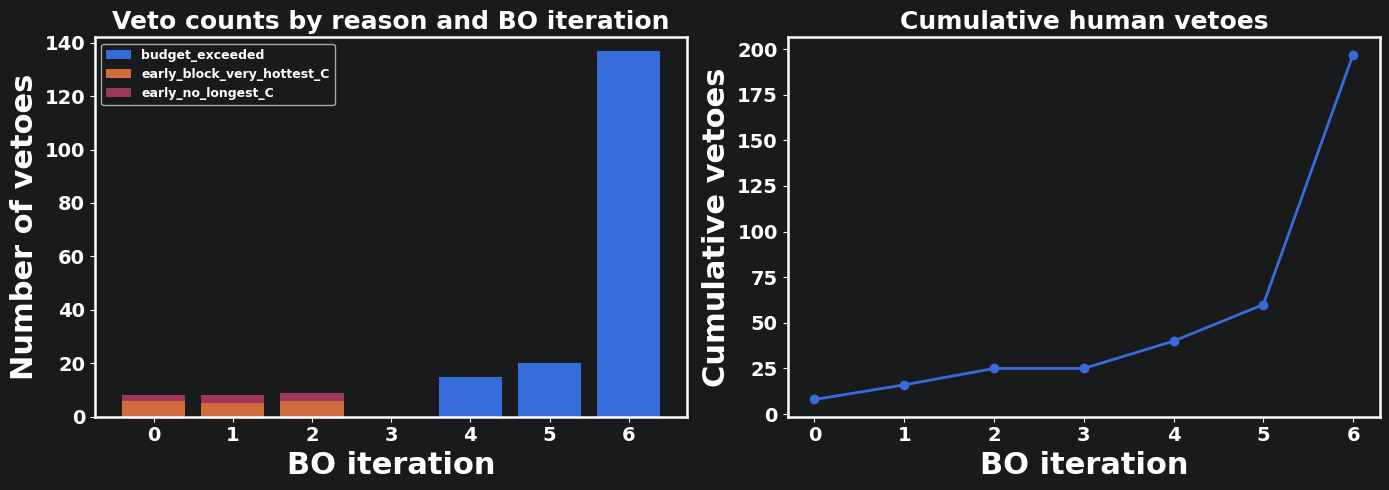

In [12]:
vetoes_per_iteration = [h["vetoes"] for h in history_human_guided]
cumulative_vetoes = np.cumsum(vetoes_per_iteration)
iterations = [h["step"] for h in history_human_guided]

all_reasons = sorted({
    reason
    for h in history_human_guided
    for reason in h.get("veto_reason_counts", {}).keys()
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bottom = np.zeros(len(history_human_guided), dtype=float)
for reason in all_reasons:
    counts = np.array([
        h.get("veto_reason_counts", {}).get(reason, 0)
        for h in history_human_guided
    ], dtype=float)

    axes[0].bar(iterations, counts, bottom=bottom, label=reason)
    bottom += counts

axes[0].set_title("Veto counts by reason and BO iteration", fontsize=18, fontweight="bold")
axes[0].set_xlabel("BO iteration", fontsize=22, fontweight="bold")
axes[0].set_ylabel("Number of vetoes", fontsize=22, fontweight="bold")
axes[0].set_ylim(0, np.max(bottom) + 5)
style_ax(axes[0])
axes[0].legend(prop={"size": 9, "weight": "bold"})

axes[1].plot(iterations, cumulative_vetoes, "-o", linewidth=2.0)
axes[1].set_title("Cumulative human vetoes", fontsize=18, fontweight="bold")
axes[1].set_xlabel("BO iteration", fontsize=22, fontweight="bold")
axes[1].set_ylabel("Cumulative vetoes", fontsize=22, fontweight="bold")
style_ax(axes[1])

plt.tight_layout()
plt.show()

## 12. Summarising the three workflows and preparing the main comparison diagnostics

Before plotting the final comparison figures, it is useful to gather the key performance information from each workflow into a compact and interpretable form.

That is what this cell does.

It defines a few small helper functions that extract:

- how the **best observed score** evolves during the run,
- how that same best score should be viewed against **cumulative cost**,
- and what the **final best repaired design** looks like for each workflow.

So this cell acts as the bridge between:

- the three BO runs already completed,
and
- the final comparison tables and figures that follow.

---

### What `extract_best_over_iterations(...)` does

The function

```python
extract_best_over_iterations(history, final_Y)
```

constructs the best-so-far performance curve as a function of **BO iteration**.

For each stored BO state, it records:

```python
float(torch.max(h["train_Y"]))
```

which is the best score available in the dataset at that point in the run.

So this helper is used to answer the question:

> **How quickly did each workflow improve its best observed score as BO iterations progressed?**

This is the natural quantity for the left-hand comparison plot later in the notebook.

The fallback case:

```python
if len(best_vals) == 0:
    best_vals = [float(torch.max(final_Y))]
```

is just a safety guard in case a workflow has no stored history entries.

---

### What `extract_best_over_cost(...)` does

The function

```python
extract_best_over_cost(history, initial_best)
```

builds a second kind of performance curve: best-so-far score as a function of **cumulative cost**.

This is especially important in this notebook, because the workflows are no longer being judged only by iteration count.
They are also being judged by how much budget they spend along the way.

The function works by tracking two running quantities:

- `running_cost`
- `running_best`

At each BO state, it appends:

- the current cumulative cost,
- and the current best observed score

before updating those values with the newly accepted candidate.

So this helper answers the question:

> **How much optimisation progress has each workflow achieved for the amount of budget spent so far?**

This is the natural quantity for the right-hand comparison plot later in the notebook.

That distinction is important:

- **best over iterations** tells us about optimisation progress by step count
- **best over cost** tells us about optimisation progress by resource expenditure

And those two views are not the same.

---

### What `best_design_summary(...)` does

The function

```python
best_design_summary(result, label, extra=None)
```

extracts the final high-level summary for a given workflow.

It looks at:

- the final dataset `train_X_final`
- the final observed scores `train_Y_final`

and finds the index of the best observed design:

```python
best_idx = torch.argmax(final_Y)
```

It then decodes and repairs that best latent point so that the summary is reported in meaningful experimental terms.

The returned row contains:

- the workflow name
- the best score found
- the total cost spent
- the total number of evaluations including the initial dataset
- the best repaired temperature
- the best repaired loading
- the best repaired time
- the best repaired solvent

So this function gives the notebook a clean final summary of what each workflow actually achieved.

This is especially useful because it moves the discussion away from abstract latent points and back to the repaired catalyst conditions that the workflows would recommend experimentally.

---

### Why `extra=...` is used for the human-guided workflow

The human-guided workflow carries one more important diagnostic than the other two workflows: **veto count**.

That is why the final row for the human-guided method is created as:

```python
extra={"Total vetoes": int(np.sum([h["vetoes"] for h in history_human_guided]))}
```

This adds the total number of candidate rejections accumulated during the run.

That quantity is useful because it tells us how much intervention the human-guided workflow applied in total.

So the summary table is not only reporting performance and cost.
For the human-guided method, it also reports how strongly the workflow filtered candidate proposals.

---

### What `summary_df` represents

The final dataframe:

```python
summary_df = pd.DataFrame([...])
```

collects one summary row for each of the three workflows:

- **Standard BO**
- **Budget-aware BO**
- **Human-guided BO**

So the dataframe acts as a compact cross-workflow comparison table.

It lets us compare, in one place:

- optimisation quality,
- total spend,
- total evaluation count,
- best repaired experimental recommendation,
- and, where relevant, total vetoes.

That makes it a very useful checkpoint before moving on to the final visual comparisons.

---

### Why this cell matters

Without this cell, the notebook would still have all the information needed for the final figures, but it would be scattered across the individual result objects and histories.

This helper layer makes the later plotting code much cleaner and easier to interpret.

More importantly, it reinforces one of the main lessons of the notebook:

> in budget-aware and workflow-aware BO, the final comparison is not only about the best score.

It is also about:

- how much cost was spent,
- how many evaluations were supported,
- what repaired design was finally reached,
- and how the workflow behaved along the way.

So this cell gathers exactly the quantities needed for that broader comparison.

---

### Key takeaway

This cell defines helper functions that extract the three most important summary views of the BO workflows:

- **best score over BO iterations**
- **best score over cumulative cost**
- **final workflow-level summary of the best repaired design**

It then combines those summaries into a dataframe comparing the three workflows directly.

So this cell prepares the key quantities needed for the final performance plots and the overall workflow comparison.

In [13]:
def extract_best_over_iterations(history, final_Y):
    best_vals = [float(torch.max(h["train_Y"])) for h in history]
    if len(best_vals) == 0:
        best_vals = [float(torch.max(final_Y))]
    return best_vals

def extract_best_over_cost(history, initial_best):
    costs = []
    bests = []
    running_cost = 0.0
    running_best = initial_best

    for h in history:
        bests.append(running_best)
        costs.append(running_cost)
        candidate_cost = h["candidate_cost"]
        if candidate_cost is not None:
            running_cost += float(candidate_cost)
        train_y = h["train_Y"]
        running_best = max(running_best, float(torch.max(train_y)))

    return costs, bests

def best_design_summary(result, label, extra=None):
    final_X = result["train_X_final"]
    final_Y = result["train_Y_final"]
    best_idx = torch.argmax(final_Y)
    best_x = final_X[best_idx]
    repaired = repair_single_design(decode_single_design(best_x))

    row = {
        "Workflow": label,
        "Best score": float(final_Y[best_idx]),
        "Total cost spent": result["total_cost"],
        "Total evaluations incl. initial data": final_X.shape[0],
        "Best repaired temperature": repaired["temperature"],
        "Best repaired loading": repaired["loading"],
        "Best repaired time": repaired["time"],
        "Best repaired solvent": repaired["solvent"],
    }
    if extra is not None:
        row.update(extra)
    return row

summary_df = pd.DataFrame([
    best_design_summary(standard_budget_result, "Standard BO"),
    best_design_summary(budget_aware_result, "Budget-aware BO"),
    best_design_summary(
        human_guided_result,
        "Human-guided BO",
        extra={"Total vetoes": int(np.sum([h["vetoes"] for h in history_human_guided]))},
    ),
])

summary_df

,Workflow,Best score,Total cost spent,Total evaluations incl. initial data,Best repaired temperature,Best repaired loading,Best repaired time,Best repaired solvent,Total vetoes
0,Standard BO,58.142291,52.2,12,118.0,0.08,40,C,NaN
1,Budget-aware BO,57.685063,56.2,25,95.0,0.11,30,B,NaN
2,Human-guided BO,65.122226,59.2,14,125.0,0.09,40,C,197.0


## 13. Comparing the three workflows through performance-by-iteration and performance-by-cost

This cell produces the two most important comparison plots in the notebook.

Up to this point, we have defined and run three different BO workflows on exactly the same mixed-variable constrained catalyst problem:

- **Standard BO**
- **Budget-aware BO**
- **Human-guided BO**

What remains is to compare them in a way that reflects the actual purpose of the tutorial.

That is why this cell plots performance against **two different horizontal axes**:

- **BO iteration**
- **cumulative cost**

This distinction is crucial.

If we only looked at BO iteration, we would mainly be asking:

> **Which workflow improves fastest per optimisation step?**

If we only looked at total cost, we would instead be asking:

> **Which workflow gets the most value from the experimental budget spent so far?**

For a practical optimisation workflow, those are not the same question.

So this cell is the key analytical comparison of the notebook.

---

### What the helper outputs represent

The line `initial_best_score = float(torch.max(train_Y_init))` stores the best score already present in the initial dataset.

That matters because all three workflows start from the same initial Sobol design, so later comparisons should be interpreted relative to a shared starting point.

The next three lines construct the best-so-far score trajectories as functions of **BO iteration** for the three workflows:

- `best_standard`
- `best_budget`
- `best_human`

These are the curves used in the **left panel**.

The following three lines construct the best-so-far score trajectories as functions of **cumulative cost**:

- `cost_standard, best_cost_standard`
- `cost_budget, best_cost_budget`
- `cost_human, best_cost_human`

These are the curves used in the **right panel**.

The plotting code then places these two perspectives side by side so that the same workflows can be judged from both views.

---

### Left panel: best observed score by BO iteration

The left panel answers the question:

> **How quickly does each workflow improve as BO steps are taken?**

This plot shows a clear difference in behaviour.

#### Standard BO

The standard workflow improves quickly and reaches a score around **58.1** in only a few steps.

This is consistent with its decision rule: it follows the acquisition function directly and is willing to spend aggressively on statistically attractive candidates.

So in terms of **raw BO iteration**, standard BO looks very efficient.

#### Budget-aware BO

The budget-aware workflow reaches a very similar plateau, around **57.7**, but it does **not** exceed the standard baseline.

This is an important point:

> **Budget-aware BO does not necessarily lead to better final results.**

That is not its purpose.

Its purpose is to spend the budget more carefully, not to guarantee a higher best score in every run.

In this plot, budget-aware BO appears slightly weaker in raw best score than standard BO.
That is perfectly plausible, because it is explicitly willing to trade a small amount of optimisation aggressiveness for a more cost-conscious decision rule.

So this result should not be judged as a failure.
It is an example of a workflow that sacrifices a little in score in exchange for a more careful use of limited resources.

#### Human-guided BO

The human-guided workflow behaves differently again.

It first climbs to a region comparable to the other methods, and then makes a further jump to about **65.1**, clearly outperforming both standard and budget-aware BO.

That is a striking result.

But it should be interpreted carefully.

The human-guided workflow did **not** discover a better result merely because “human guidance is always better.”
It achieved this because the additional decision layer shaped the search trajectory in a particular way.

In this run, the human-style rules and soft preferences delayed some early aggressive decisions, but still allowed the workflow to reach a stronger high-performing region later.

So the left panel shows that:

> **Human-guided BO can achieve better results than both standard and budget-aware BO, but that depends strongly on how the guiding rules are defined.**

---

### Right panel: best observed score by cumulative cost

The right panel answers a different and arguably more practical question:

> **How much optimisation progress is achieved for the amount of budget spent so far?**

This is where the budget-aware nature of the notebook becomes most visible.

#### Standard BO

The standard BO curve reaches its plateau relatively early, but only after spending a substantial amount of budget.

It is efficient in terms of iterations, but not necessarily the most cautious in terms of cost.

So the standard policy still reflects an acquisition-first mentality.

#### Budget-aware BO

This curve is the clearest illustration of the purpose of the budget-aware method.

It reaches a score that is **virtually the same** as the standard BO baseline, but it does so in a more cost-conscious manner.

This leads directly to one of the central conclusions of the notebook:

> **Budget-aware BO does not necessarily produce a better final result, but it can achieve similar performance under lower cost or a more favourable budget profile.**

That is the key point.

The goal of budget-aware BO is not simply to win on raw best score.
Its purpose is to improve the **score–cost tradeoff**.

So a result like this is exactly what we should be willing to call a success:

- nearly the same performance
- lower or more controlled expenditure
- and a decision path that stretches the same budget further

This is a much more realistic optimisation objective for experimental workflows.

#### Human-guided BO

The human-guided curve is especially interesting here because it not only reaches a **better final score**, but also does so at a total cost that remains competitive with the other workflows.

So in this run, the human-guided policy appears to give both:

- **better final performance**
- and a still-reasonable cost trajectory

That makes it look very strong.

But again, this requires care in interpretation.

---

### What we should conclude from the human-guided result

The most tempting interpretation would be:

> “Human-guided BO is best.”

But that would be too strong.

A better conclusion is:

> **Human-guided BO can outperform the purely algorithmic workflows when the additional guidance is well aligned with the structure of the problem.**

That is a more defensible statement.

In this notebook, the human-guided strategy depends on a hand-designed “marking scheme” consisting of:

- early-stage veto rules
- soft preference bonuses
- mild cost aversion
- and explicit reward for solvent C designs that are close to the known good region

So the human-guided policy is not neutral.
It encodes a particular view of what kinds of experiments should be favoured or delayed.

That means the strong performance of the human-guided workflow depends on how well that marking scheme matches the actual structure of the synthetic optimisation problem.

So the correct lesson is not:

- “human guidance always helps”

but rather:

- **human guidance can help a great deal if the rules reflect useful prior judgement**
- **and it can also hurt if the rules are poorly chosen**

That is exactly why this tutorial is interesting.
It shows both the promise and the subjectivity of human-in-the-loop BO.

---

### Why these two panels must be read together

It would be a mistake to look at only one of these plots.

If we looked only at the left panel, we might say:

- standard BO is strong
- budget-aware BO is slightly worse
- human-guided BO is best

But if we also look at the right panel, the interpretation becomes richer:

- standard BO improves quickly, but spends budget aggressively
- budget-aware BO reaches nearly the same level while being more cost-conscious
- human-guided BO can outperform both, but only because the hand-designed guidance happened to be beneficial here

So the two-panel view is essential.

It makes clear that optimisation workflows should not be judged only by their final best score, but by the broader question:

> **How effectively did the workflow convert limited experimental budget into useful optimisation progress?**

That is the real theme of the notebook.

---

### Main conclusions from this figure

This figure supports several important conclusions.

#### 1. Budget-aware BO does not necessarily produce better final results

The budget-aware workflow in this run does **not** outperform standard BO in best observed score.

That is perfectly acceptable.

Its purpose is not to dominate standard BO in raw score, but to make the search more cost-aware.

#### 2. Budget-aware BO can achieve similar performance under lower cost

This is the most important lesson of the budget-aware comparison.

A workflow can be valuable even if it reaches a similar rather than strictly better optimum, provided that it does so with a better score–cost tradeoff.

That is exactly what the budget-aware curve illustrates.

#### 3. Human-guided BO can achieve better results at competitive or lower effective cost

In this run, the human-guided workflow reaches a noticeably better best score while maintaining a still-reasonable budget trajectory.

So human-in-the-loop BO can indeed be powerful.

#### 4. But the success of human-guided BO depends on how the “marking scheme” is set up

This is the crucial caveat.

The human-guided result depends strongly on the hand-designed rules, bonuses, and vetoes used in the workflow.

So its superiority here should be understood as:

- evidence that **good guidance can help**
- not evidence that **any human intervention will help**

That distinction matters.

---

### Key takeaway

This cell produces the two central comparison plots of the notebook and makes the main workflow-level lessons visible.

- **Standard BO** is strong in raw step-by-step optimisation, but spends budget aggressively.
- **Budget-aware BO** does not necessarily achieve a better final result, but it can achieve **similar performance with a more favourable budget profile**.
- **Human-guided BO** can achieve **better results at competitive cost**, but this depends strongly on how the guiding rules and preferences are designed.

So the most important conclusion is not simply which curve is highest.

It is that, once experimental cost and workflow judgement matter, the quality of a BO strategy must be judged through a broader lens than best score alone.This cell produces the two most important comparison plots in the notebook.

Up to this point, we have defined and run three different BO workflows on exactly the same mixed-variable constrained catalyst problem:

- **Standard BO**
- **Budget-aware BO**
- **Human-guided BO**

What remains is to compare them in a way that reflects the actual purpose of the tutorial.

That is why this cell plots performance against **two different horizontal axes**:

- **BO iteration**
- **cumulative cost**

This distinction is crucial.

If we only looked at BO iteration, we would mainly be asking:

> **Which workflow improves fastest per optimisation step?**

If we only looked at total cost, we would instead be asking:

> **Which workflow gets the most value from the experimental budget spent so far?**

For a practical optimisation workflow, those are not the same question.

So this cell is the key analytical comparison of the notebook.

---

### What the helper outputs represent

The first line:

```python
initial_best_score = float(torch.max(train_Y_init))

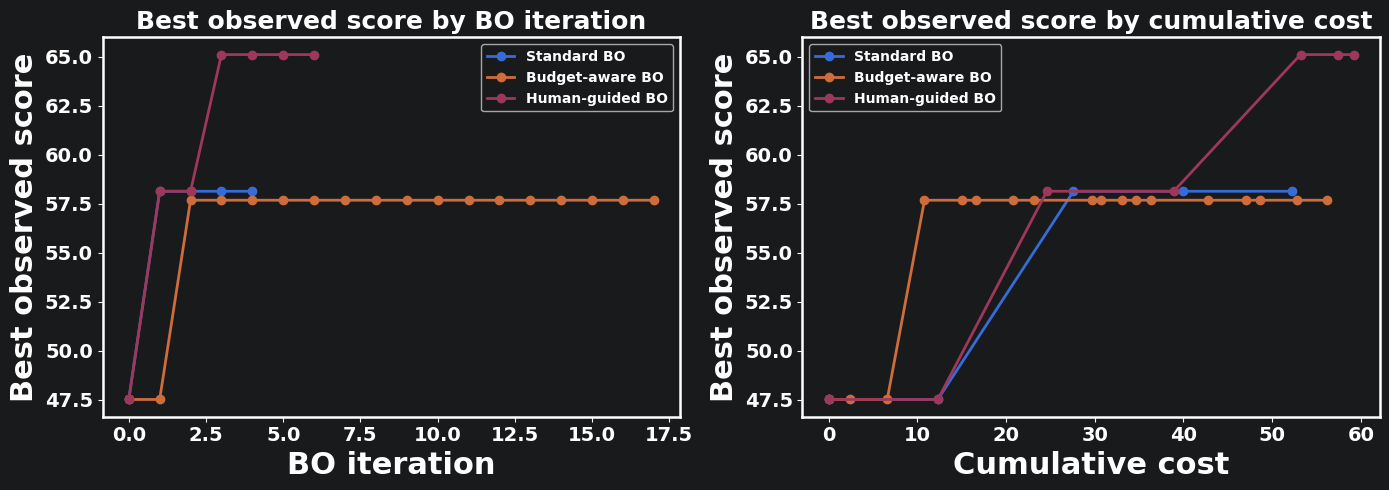

In [14]:
initial_best_score = float(torch.max(train_Y_init))

best_standard = extract_best_over_iterations(history_standard_budget, standard_budget_result["train_Y_final"])
best_budget = extract_best_over_iterations(history_budget_aware, budget_aware_result["train_Y_final"])
best_human = extract_best_over_iterations(history_human_guided, human_guided_result["train_Y_final"])

cost_standard, best_cost_standard = extract_best_over_cost(history_standard_budget, initial_best_score)
cost_budget, best_cost_budget = extract_best_over_cost(history_budget_aware, initial_best_score)
cost_human, best_cost_human = extract_best_over_cost(history_human_guided, initial_best_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(len(best_standard)), best_standard, "-o", linewidth=2.0, label="Standard BO")
axes[0].plot(range(len(best_budget)), best_budget, "-o", linewidth=2.0, label="Budget-aware BO")
axes[0].plot(range(len(best_human)), best_human, "-o", linewidth=2.0, label="Human-guided BO")
axes[0].set_title("Best observed score by BO iteration", fontsize=18, fontweight="bold")
axes[0].set_xlabel("BO iteration", fontsize=22, fontweight="bold")
axes[0].set_ylabel("Best observed score", fontsize=22, fontweight="bold")
style_ax(axes[0])
axes[0].legend(prop={"size": 10, "weight": "bold"})

axes[1].plot(cost_standard, best_cost_standard, "-o", linewidth=2.0, label="Standard BO")
axes[1].plot(cost_budget, best_cost_budget, "-o", linewidth=2.0, label="Budget-aware BO")
axes[1].plot(cost_human, best_cost_human, "-o", linewidth=2.0, label="Human-guided BO")
axes[1].set_title("Best observed score by cumulative cost", fontsize=18, fontweight="bold")
axes[1].set_xlabel("Cumulative cost", fontsize=22, fontweight="bold")
axes[1].set_ylabel("Best observed score", fontsize=22, fontweight="bold")
style_ax(axes[1])
axes[1].legend(prop={"size": 10, "weight": "bold"})

plt.tight_layout()
plt.show()

## 14. Comparing accepted candidate cost and total accepted evaluations

This cell adds a second layer of workflow comparison by looking not only at **what score each method achieved**, but also at **what kinds of experiments it chose to spend budget on**.

That is useful because the previous figure showed the main optimisation outcomes, but it did not fully reveal the different **spending styles** of the three workflows.

This figure helps answer two additional questions:

- **How expensive were the accepted experiments over time?**
- **How many accepted evaluations did each workflow manage to complete under the same total budget?**

Those are both highly relevant in realistic experimental BO settings.

---

### What the two panels show

#### Left panel: accepted candidate cost by BO iteration
This plot shows the cost of each **accepted** BO-guided candidate over the course of the run.

So it reveals the spending pattern of each workflow step by step.

#### Right panel: cumulative accepted evaluations by workflow
This bar chart shows how many **accepted BO-guided evaluations** each workflow completed before the run ended.

This is a direct measure of how far each workflow was able to stretch the available budget.

---

### Behaviour of the standard BO workflow

The standard BO curve is concentrated at the top of the cost range.

Its accepted candidate costs are consistently high, roughly in the **12–15** range throughout the run.

This is exactly what we should expect from the standard budget-limited BO strategy.

Because it chooses candidates using acquisition value alone, it is willing to spend heavily on statistically attractive regions without explicitly worrying about cost efficiency.

So the standard workflow behaves like a relatively aggressive spender:

- it accepts expensive experiments,
- it reaches a good score quickly,
- but it burns through the available budget very fast.

That is why the right-hand bar chart shows that standard BO completes only **5 accepted evaluations**.

So the standard strategy is efficient in terms of raw optimisation steps, but not at all efficient in terms of **budget endurance**.

---

### Behaviour of the budget-aware BO workflow

The budget-aware curve is almost the opposite.

Its accepted candidate costs are much lower overall, mostly concentrated in the **1–6** range, with many experiments being very cheap relative to the other two methods.

This is exactly the behaviour the budget-aware utility rule was designed to encourage.

Because the workflow selects candidates using:

\[
\text{utility} = \text{acquisition value} - \lambda \times \text{cost},
\]

it is actively encouraged to avoid expensive experiments unless they offer a sufficiently strong gain.

So the left-hand panel shows the budget-aware policy behaving as intended:

- it systematically prefers cheaper candidates,
- it avoids the persistent high-cost spending pattern of standard BO,
- and it uses the budget in a much more gradual way.

This directly explains the result in the right-hand panel:

- the budget-aware workflow completes **17 accepted evaluations**

which is far more than either of the other two methods.

This is one of the clearest pieces of evidence in the notebook that:

> **budget-aware BO can stretch the same total budget much further than standard BO.**

At the same time, from the previous figure we already know that it did this while achieving a **very similar final best score**.

So this panel reinforces the key interpretation:

> budget-aware BO is not mainly trying to beat standard BO in raw score, but to achieve a better score–cost tradeoff by supporting many more affordable evaluations.

---

### Behaviour of the human-guided BO workflow

The human-guided workflow behaves differently again.

In the early iterations, its accepted candidate costs are also quite high, similar to the standard BO workflow.
The first few accepted experiments sit around the **12–14** range.

This reflects the fact that the human-guided workflow is **not primarily a cost-minimisation policy**.
It is instead a workflow shaped by:

- early-stage veto rules,
- soft preference bonuses,
- and only mild cost aversion.

So unlike budget-aware BO, it is still willing to accept expensive experiments when they look promising or align with the human-style preference structure.

But then something interesting happens:

- after those early high-cost steps, the accepted candidate cost drops sharply,
- and later accepted candidates become much cheaper.

So the human-guided workflow appears to behave like a **staged policy**:

- early on, it is willing to invest in some expensive experiments,
- later on, it becomes much less expensive per accepted step.

This staged behaviour is very different from the more uniform pattern of the standard and budget-aware workflows.

In the right-hand bar chart, this leads to:

- **6 accepted evaluations**

So human-guided BO supports only slightly more accepted evaluations than standard BO, and far fewer than budget-aware BO.

That makes sense.

This workflow is not trying to maximise the number of evaluations.
It is trying to steer the search using a combination of judgement and mild cost sensitivity, which in this run happened to produce a stronger final score.

---

### What this figure adds beyond the previous one

The previous main comparison figure already showed that:

- standard BO reaches a good score quickly,
- budget-aware BO reaches a similar score more cost-consciously,
- and human-guided BO can reach a better final score in this particular setup.

This figure explains **how** those outcomes happened.

It shows that:

- **Standard BO** spends heavily and therefore runs out of budget quickly
- **Budget-aware BO** deliberately keeps accepted candidate costs low, which is why it can run so many more evaluations
- **Human-guided BO** mixes some early expensive choices with later cheaper ones, giving it a more staged and uneven cost profile

So this figure turns the earlier score comparison into a clearer workflow interpretation.

---

### Main conclusions from this figure

#### 1. Standard BO is the most aggressive spender
Its accepted candidate costs stay high across the run, which causes it to exhaust the budget after only a small number of evaluations.

#### 2. Budget-aware BO is the most evaluation-efficient
By consistently choosing lower-cost candidates, it supports **many more accepted evaluations** than either alternative.

This is the clearest operational benefit of the budget-aware policy.

#### 3. Human-guided BO is not mainly optimising for evaluation count
It accepts relatively expensive candidates early on, so its total number of accepted evaluations remains low compared with budget-aware BO.

Its strength in this notebook lies more in **where** it chooses to spend than in **how many** experiments it can afford.

#### 4. Cost behaviour helps explain the earlier performance curves
This figure makes the earlier results much easier to understand:

- standard BO gets fewer but expensive shots,
- budget-aware BO gets many cheaper shots,
- human-guided BO gets relatively few shots, but in this run they happened to be directed more effectively.

---

### Key takeaway

This figure shows that the three workflows do not just differ in optimisation performance; they differ in **how they spend experimental budget**.

- **Standard BO** accepts consistently expensive candidates and therefore supports only a few evaluations.
- **Budget-aware BO** deliberately keeps candidate cost low, which allows it to complete far more accepted evaluations under the same total budget.
- **Human-guided BO** follows a more staged spending pattern, with expensive early choices followed by cheaper later ones.

So the figure reinforces one of the central lessons of the notebook:

> once cost matters, BO workflows should be compared not only by the final score they achieve, but also by the *kind of experimental spending pattern* they induce.

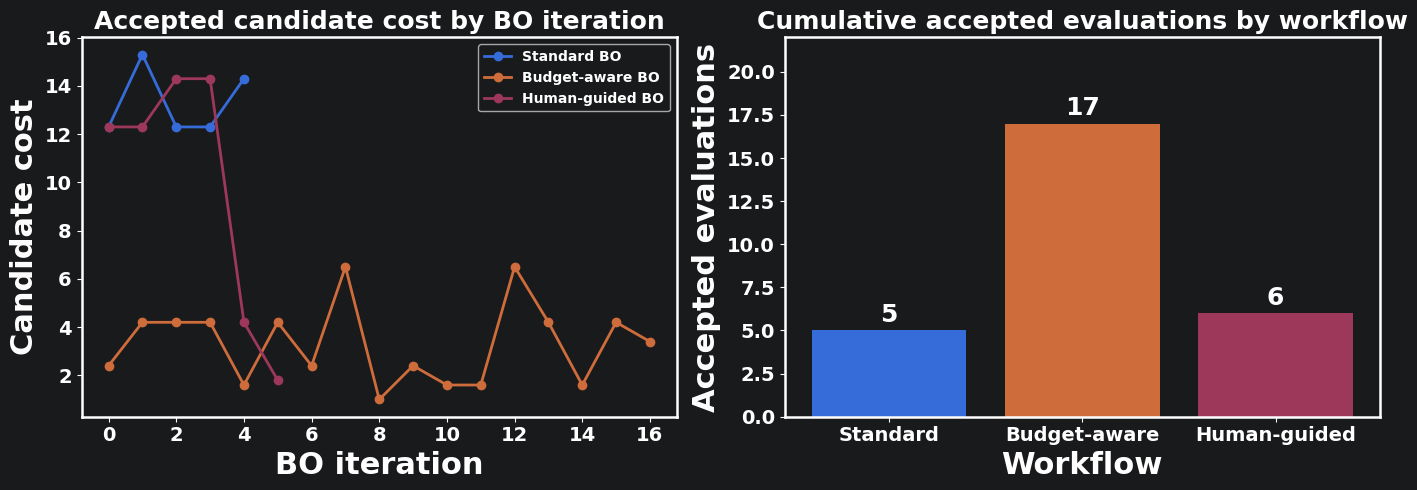

In [15]:
standard_candidate_costs = [h["candidate_cost"] for h in history_standard_budget if h["candidate_cost"] is not None]
budget_candidate_costs = [h["candidate_cost"] for h in history_budget_aware if h["candidate_cost"] is not None]
human_candidate_costs = [h["candidate_cost"] for h in history_human_guided if h["candidate_cost"] is not None]

workflow_labels = ["Standard", "Budget-aware", "Human-guided"]
accepted_evals = [
    sum(h["candidate_cost"] is not None for h in history_standard_budget),
    sum(h["candidate_cost"] is not None for h in history_budget_aware),
    sum(h["candidate_cost"] is not None for h in history_human_guided),
]
bar_colors = ["#366CD9", "#CE6C3B", "#9E385A"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    range(len(standard_candidate_costs)),
    standard_candidate_costs,
    "-o",
    linewidth=2.0,
    label="Standard BO",
)
axes[0].plot(
    range(len(budget_candidate_costs)),
    budget_candidate_costs,
    "-o",
    linewidth=2.0,
    label="Budget-aware BO",
)
axes[0].plot(
    range(len(human_candidate_costs)),
    human_candidate_costs,
    "-o",
    linewidth=2.0,
    label="Human-guided BO",
)
axes[0].set_title("Accepted candidate cost by BO iteration", fontsize=18, fontweight="bold")
axes[0].set_xlabel("BO iteration", fontsize=22, fontweight="bold")
axes[0].set_ylabel("Candidate cost", fontsize=22, fontweight="bold")
style_ax(axes[0])
axes[0].legend(prop={"size": 10, "weight": "bold"})

bars = axes[1].bar(workflow_labels, accepted_evals, color=bar_colors)
axes[1].set_title("Cumulative accepted evaluations by workflow", fontsize=18, fontweight="bold")
axes[1].set_xlabel("Workflow", fontsize=22, fontweight="bold")
axes[1].set_ylabel("Accepted evaluations", fontsize=22, fontweight="bold")
axes[1].set_ylim(0, np.max(accepted_evals) + 5)
style_ax(axes[1])

for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=18,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## 🧭 Closing Remarks

In this tutorial, we moved from **mixed-variable, constrained Bayesian Optimisation in a repaired experimental design space** to the problem of running BO under **explicit budget limits and human-guided workflow constraints**.

The central idea was that once each BO evaluation has an associated **cost**, and once candidate selection may be shaped not only by the acquisition function but also by **practical decision rules**, the optimisation problem changes in an important way.

The challenge is no longer only:

- how to fit a surrogate,
- how to define an acquisition function,
- and how to repeat the BO loop,

but also:

- how to represent the fact that different experiments cost different amounts,
- how to compare BO policies when budget is limited,
- how to decide whether a candidate is worth running *now* rather than only whether it looks promising,
- and how to model the effect of simple human-style intervention on the optimisation trajectory.

At a structural level, the BO workflow still followed the same general pattern:

1. fit a Gaussian Process surrogate to the currently observed data,
2. build an acquisition rule from that surrogate,
3. propose the next candidate,
4. evaluate the objective there,
5. update the dataset,
6. and repeat.

But the meaning of a “good next candidate” changed.

In the earlier notebooks, once a repaired feasible design had been defined, BO mainly asked:

> **which candidate looks best according to the optimisation rule?**

Here, that was no longer enough.

A candidate also had to be judged in terms of:

- how much budget it would consume,
- whether it was worth spending that budget at the current stage,
- and, in the human-guided case, whether it passed a layer of practical screening before acceptance.

That shift was the whole point of the notebook.

Instead of treating BO as a process that optimises only for performance, we treated it as something that must still function when the real question becomes:

> **which experiment is worth spending limited resources on next?**

That is much closer to many real scientific workflows.

Across the notebook, we kept exactly the same synthetic **mixed-variable catalyst optimisation** problem introduced previously:

- temperature,
- loading,
- reaction time,
- and solvent identity,

together with the same decode–repair–evaluate pipeline.

That continuity was important.

It meant that the design space itself did not change.
What changed was the **decision logic layered on top of it**.

So the first important lesson was that budget-aware and workflow-aware BO are not about replacing the whole BO framework.

They are about changing **how next experiments are selected** once practical constraints matter.

That is why this tutorial introduced three distinct workflows built on the same repaired catalyst problem:

- a **standard budget-limited BO** loop,
- a **budget-aware BO** loop,
- and a **human-guided BO** loop.

This was the main methodological achievement of the notebook.

The three workflows used:

- the same repaired objective,
- the same latent search representation,
- the same GP surrogate class,
- and the same acquisition framework,

but they differed in how they interpreted the value of a candidate experiment.

That made the comparisons especially meaningful.

The **standard BO** workflow remained the natural baseline.

It still selected candidates using the acquisition function alone and only stopped when the next experiment would exceed the available budget.

So this method represented the simplest answer to the question:

> what happens if we run ordinary BO, but in a world where experiments cost money?

The **budget-aware BO** workflow changed only one part of that logic, but it changed something very important:

- it evaluated a diverse candidate pool,
- it attached an explicit cost to each repaired candidate,
- and it selected the next experiment using an acquisition–cost utility rather than acquisition value alone.

This led to one of the most important practical lessons of the notebook:

> budget-aware BO does not necessarily need to achieve a better final optimum to be useful.

In our results, the budget-aware workflow did **not** beat standard BO in raw best observed score.

But that is not a weakness of the method.
It is exactly the point.

It reached a **very similar final performance** while accepting far cheaper experiments on average and supporting **many more accepted evaluations** under the same overall budget.

That was one of the clearest outcomes in the notebook.

It showed that:

> better BO behaviour under budget constraints does not necessarily mean a higher final score; it can also mean a **better score–cost tradeoff**.

That is often exactly what matters in real experimental settings.

If one BO evaluation corresponds to:

- a synthesis,
- a reaction run,
- a long instrument slot,
- or a costly simulation,

then a workflow that reaches nearly the same performance while spending budget more gradually can be extremely valuable.

So one of the main practical conclusions of the notebook was:

> under limited resources, a BO workflow can be better not because it finds a different final optimum, but because it uses the budget **more intelligently**.

The **human-guided BO** workflow then pushed this idea one step further.

Instead of letting candidate choice be determined only by an algorithmic rule, it introduced an explicit additional layer of decision-making:

- early-stage vetoes for especially aggressive conditions,
- soft preference bonuses,
- a mild cost penalty,
- and a fallback mechanism when the main candidate pool was too restrictive.

This was an important conceptual step.

It showed that BO can be embedded inside a workflow where the next experiment is not chosen by the acquisition function alone, nor even by acquisition–cost utility alone, but by a combination of:

- surrogate-based statistical reasoning,
- resource constraints,
- and a stylised version of human judgement.

The results made this especially interesting.

In our run, the human-guided workflow reached a **better final score** than both the standard and budget-aware methods, while remaining competitive in total spend.

That is a strong result.

But the notebook also made clear that this should be interpreted carefully.

The human-guided strategy worked well here **because of how the marking scheme was defined**:

- which candidates were blocked early,
- which kinds of repaired designs received preference bonuses,
- and how cost was weighted relative to acquisition value.

So one of the most important lessons of the notebook was:

> human-guided BO *can* outperform purely algorithmic BO, but whether it does so depends strongly on how the guidance rules are designed.

That is both the promise and the danger of human-in-the-loop optimisation.

Good guidance can help a great deal.
Poor guidance can distort the search or suppress promising regions.

So the notebook did not show that human input is automatically superior.
It showed something more realistic:

> once BO is embedded in a practical decision process, the quality of that decision layer matters enormously.

The diagnostics then made these workflow differences concrete.

The main best-score comparison showed that:

- **standard BO** improved quickly but spent budget aggressively,
- **budget-aware BO** reached nearly the same level with a much more economical spending pattern,
- and **human-guided BO** could, in this case, reach an even stronger region because the intervention rules happened to align well with the structure of the problem.

The accepted-candidate-cost plot then exposed the spending styles directly:

- standard BO repeatedly accepted expensive experiments,
- budget-aware BO systematically preferred cheaper ones,
- and human-guided BO followed a more staged pattern, with expensive early choices followed by cheaper later decisions.

The veto diagnostics revealed another important point:

> in a human-guided workflow, rejected candidates are part of the optimisation story too.

The veto counts showed that the meaning of rejection changed during the run:

- early vetoes came mainly from staged human caution,
- later vetoes were dominated by budget exhaustion.

So even the rejected candidates taught us something about how the workflow was operating.

That is where this notebook connects most directly to real research.

In a real experimental campaign, researchers are often not asking only:

> what candidate has the highest acquisition value?

They are more often asking:

> what is the next experiment worth spending budget on, and does it make sense to run it *now*?

That is a genuinely workflow-aware BO question.

So by the end of this notebook, we have not introduced a completely different optimisation paradigm.
Instead, we have taken the BO workflow already built in the earlier tutorials and adapted it to a much more realistic mode of use:

- one in which repaired experiments carry unequal cost,
- one in which total evaluation budget is finite,
- one in which candidate selection may be utility-based rather than acquisition-only,
- and one in which human-style judgement can be layered into the loop.

That gives us a natural stopping point:

> we now know how to build, run, and interpret practical BO workflows in which performance, budget, and decision policy all matter at the same time.

Looking forward, this also gives us a natural bridge into **Part 6**.

If Part 5 was about making BO more realistic as an optimisation workflow, then Part 6 will naturally ask what happens when we turn from workflow design toward **learning, structure, and modelling at a deeper level**:

- when surrogate assumptions become more important,
- when richer uncertainty representations are needed,
- when objectives become more complex,
- or when BO must be connected more closely to the broader statistical and modelling questions behind scientific decision-making.

That is where budget-aware and human-aware BO begin to connect to the next stage of the broader project.

So the main takeaway of this tutorial is:

> once experiments are expensive and decision-making is structured, BO should not be judged only by the final score it achieves, but by **how intelligently it turns limited resources into optimisation progress**.